# Forecasting Next-Day PM2.5 in Dublin Using Mobile Air Quality, Weather, and Traffic Data

**Research question:**

Can next-day air pollution in Dublin be predicted from recent pollution levels, weather and traffic conditions, and what does this imply for DCC’s monitoring and intervention strategy?

**Target variable:** 

Particulate matter pollution, specifically PM2.5, particles with a size (diameter) of less than 2.5 micrometers 

**Rationale for PM2.5**

PM2.5 is used as the dependent variable because particulate matter is identified by Our World in Data as the main contributor to poor health from air pollution, with higher death rates than ozone, and PM2.5 is especially harmful because its very small particles can penetrate deep into the respiratory system.

**Data sources**

- Google Air View
- weather dataset *(Met Eirean Daily Historical Data at Dublin Airport)*
- traffic dataset *(TBD)*

## 1. Setup

- imports
- random seed
- file paths

In [4]:
#Import Libraries

#Basic
%matplotlib inline
import numpy as np
import pandas as pd
import math
from pathlib import Path


#Plotting
import matplotlib.pyplot as plt
import seaborn as sns

#Forecasting
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection import backtesting_forecaster
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from pandas.tseries.offsets import BusinessDay
from math import sqrt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## 2. Data loading understanding
- variable overview
- time coverage
- granularity
- missingness

### 2.1 Air View data understanding & exploration

In [5]:
data_airview = pd.read_csv('../data/raw/AirView_DublinCity_Measurements_ugm3.csv')

In [6]:
print(data_airview.shape)

(5030143, 15)


In [7]:
print(data_airview.columns)

Index(['gps_timestamp', 'latitude', 'longitude', 'NO_ugm3', 'NO2_ugm3',
       'O3_ugm3', 'CO_mgm3', 'CO2_mgm3', 'PMch1_perL', 'PMch2_perL',
       'PMch3_perL', 'PMch4_perL', 'PMch5_perL', 'PMch6_perL', 'PM25_ugm3'],
      dtype='object')


In [8]:
#Stripped DF with just PM2.5 ugm^3 and car metrics
df = data_airview[['gps_timestamp', 'latitude' , 'longitude' , 'PM25_ugm3']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030143 entries, 0 to 5030142
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   gps_timestamp  object 
 1   latitude       float64
 2   longitude      float64
 3   PM25_ugm3      float64
dtypes: float64(3), object(1)
memory usage: 153.5+ MB


In [9]:
df = df.copy()
df.loc[:, "timestamp"] = pd.to_datetime(
    df["gps_timestamp"],
    format="%Y-%m-%d %H:%M:%S %Z"
)

In [10]:
#Check for missingness
df.isna().sum()

gps_timestamp        0
latitude             0
longitude            0
PM25_ugm3        89877
timestamp            0
dtype: int64

In [11]:
#Determine the percentage of rows with missing PM2.5 recordings
missing_rows = df[df["PM25_ugm3"].isna()] #highlight row mask for plotting

percentage_missing = len(missing_rows) / len(df) * 100
print(round(percentage_missing,2), "% of all rows have missing PM2.5 values")

1.79 % of all rows have missing PM2.5 values


In [12]:
#For easy plotting add date /time column
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

In [13]:
# Basic time stats
print("Date range:", df['date'].min(), "to", df['date'].max())

total_days = (df['date'].max() - df['date'].min()).days + 1 #add 1 for  both first/last day
observed_days = df["date"].nunique() #unique dates
percentage_days = (observed_days / total_days) * 100

print(f"The car took readings on {observed_days} days out of the total {total_days} days in range"
      f"({percentage_days:.2f}% of days)")

Date range: 2021-05-06 to 2022-08-05
The car took readings on 286 days out of the total 457 days in range(62.58% of days)


In [14]:
# Car times of day
print("Time range:", df['time'].min(), "to", df['time'].max())

Time range: 06:11:07 to 19:43:31


In [15]:
#Days of week recordings
df['weekday'] = df['timestamp'].dt.day_name()
weekday_counts = df['weekday'].value_counts().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
print(weekday_counts)

weekday
Monday        912416.0
Tuesday      1132047.0
Wednesday    1019297.0
Thursday     1009116.0
Friday        957267.0
Saturday           NaN
Sunday             NaN
Name: count, dtype: float64


Evidently the car only captured measurements on weekdays, with Tuesday having the largest number of recordings. On average, Monday and Friday have the lowest number of recordings of all the weekdays.

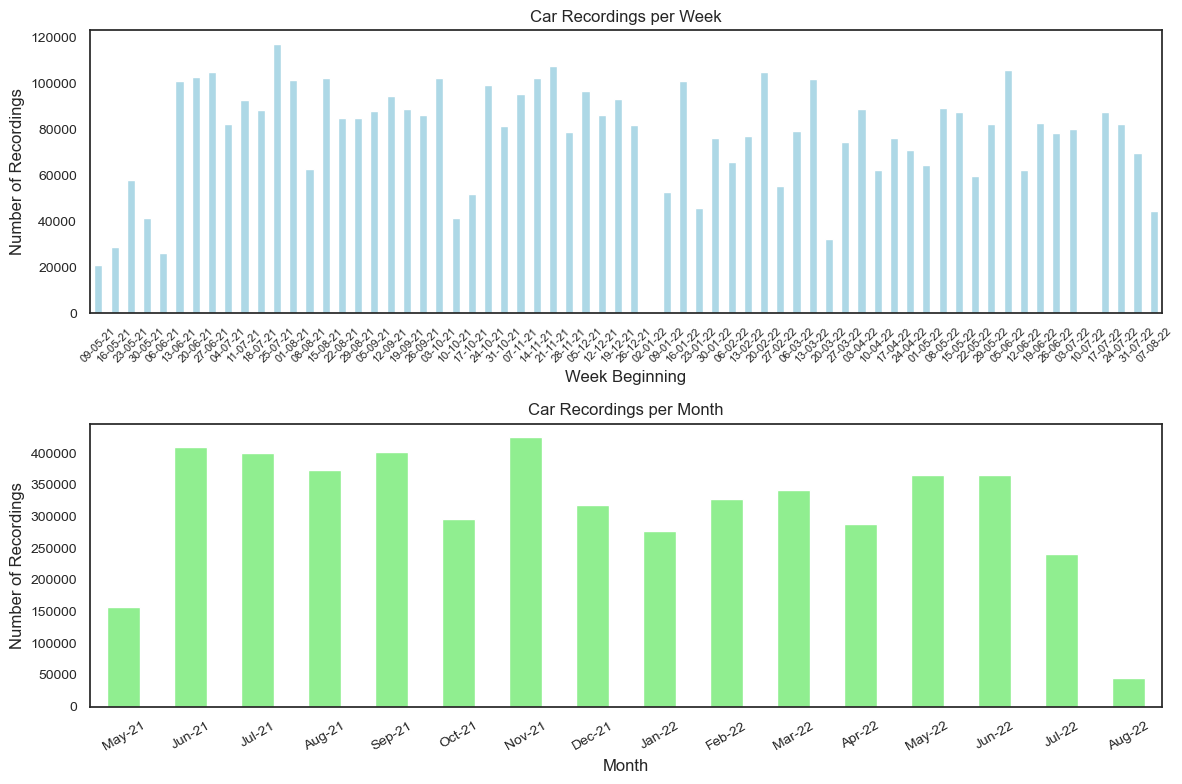

In [16]:
#Visualise recordings weekly and monthly
df['date'] = pd.to_datetime(df['date'])
weekly_counts = df.groupby(pd.Grouper(key = 'date', freq = 'W')).size()
monthly_counts = df.groupby(pd.Grouper(key = 'date', freq = 'ME')).size()

#Both in subplots
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 1, figsize=(12, 8))  # 2x1

# Weekly plot
weekly_counts.index = weekly_counts.index.strftime('%d-%m-%y')
weekly_counts.plot(ax=axes[0], kind='bar', color = 'lightblue')
axes[0].set_title('Car Recordings per Week')
axes[0].set_xlabel('Week Beginning')
axes[0].set_ylabel('Number of Recordings')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)

# Monthly plot
monthly_counts.index = monthly_counts.index.strftime('%b-%y')
monthly_counts.plot(ax=axes[1], kind='bar', color = 'lightgreen')
axes[1].set_title('Car Recordings per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Recordings')
axes[1].tick_params(axis='x', rotation=30, labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

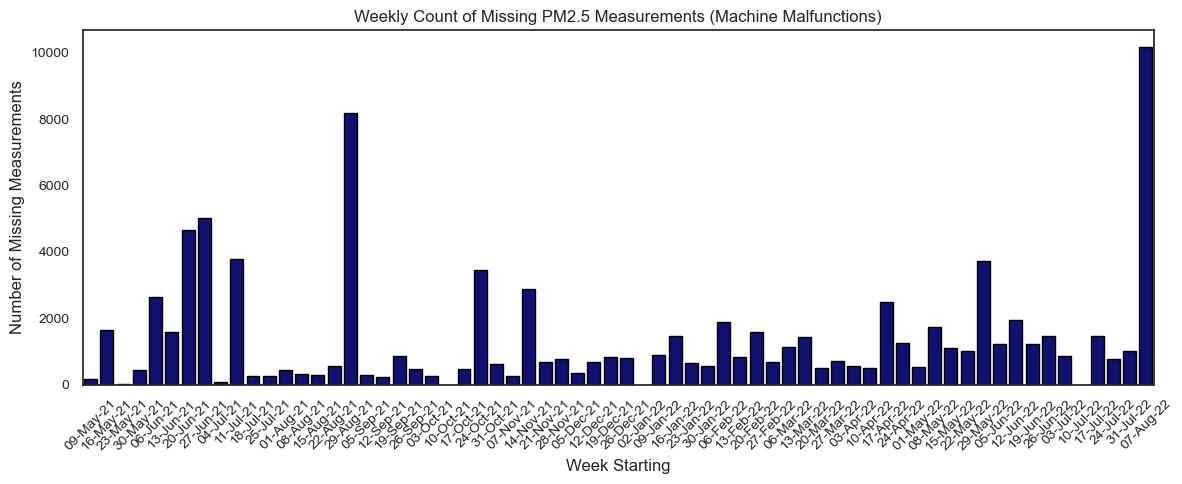

In [17]:
# Distribution of missing values

weekly_missing = df.groupby(pd.Grouper(key = 'timestamp', freq = 'W'))['PM25_ugm3'].apply(lambda x: x.isna().sum())
weekly_missing = weekly_missing.reset_index()
weekly_missing.columns = ['week_start', 'missing_count']
weekly_missing['week_label'] = weekly_missing['week_start'].dt.strftime('%d-%b-%y')

sns.set_theme(style='white')

# Plot
plt.figure(figsize=(12,5))
sns.barplot(x='week_label', y='missing_count', data=weekly_missing, color='navy', edgecolor='black')
plt.xlabel('Week Starting')
plt.ylabel('Number of Missing Measurements')
plt.title('Weekly Count of Missing PM2.5 Measurements (Machine Malfunctions)')

# Rotate x-axis
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

PM2.5 Recordings

In [18]:
# Number of unique measurements
num_unique = df['PM25_ugm3'].nunique(dropna=True)
print(f"Number of unique PM25_ugm3 measurements: {num_unique}")

#Range of Measurements
df['PM25_ugm3'].describe()
#from this can see that there are no negative recordings but some very large recordings way above mean and top quartile

Number of unique PM25_ugm3 measurements: 58495


count    4.940266e+06
mean     7.976111e+00
std      8.545271e+00
min      7.100000e-02
25%      3.574000e+00
50%      6.097000e+00
75%      1.012800e+01
max      1.960163e+03
Name: PM25_ugm3, dtype: float64

News articles remark expectionally high measures of PM2.5 of 400 in Rathmines in 2020, the highest measure since the 80s. There does not appear to be any news article reporting of any further anomaly events, suggesting that it is reasonable to assume any records beyond this level are machine errors. (https://www.breakingnews.ie/ireland/dublins-air-pollution-hits-highest-levels-since-the-1980s-1044551.html)

In [19]:
#Outliers
print(((df['PM25_ugm3'] > 400).sum()), "of the", ((df['PM25_ugm3'] > 0).sum()), 
      "readings are above 400ugm3, i.e. ", round(((df['PM25_ugm3'] > 400).mean() * 100),6), "%")

117 of the 4940266 readings are above 400ugm3, i.e.  0.002326 %


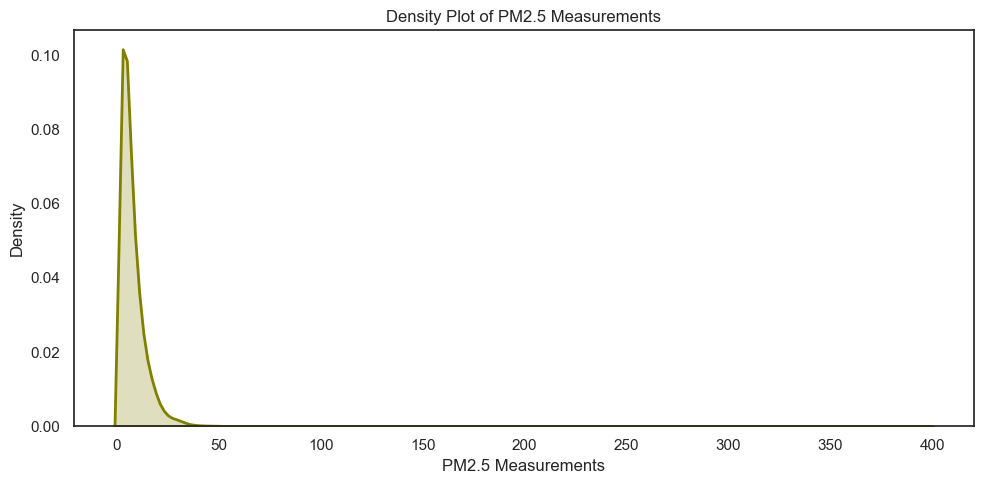

In [20]:
#Removing them
df_clean = df[df['PM25_ugm3'] <= 400].dropna()

plt.figure(figsize=(10,5))
sns.kdeplot(df_clean['PM25_ugm3'], fill=True, color='olive', linewidth=2)

plt.xlabel('PM2.5 Measurements')
plt.ylabel('Density')
plt.title('Density Plot of PM2.5 Measurements')

plt.tight_layout()
plt.show()

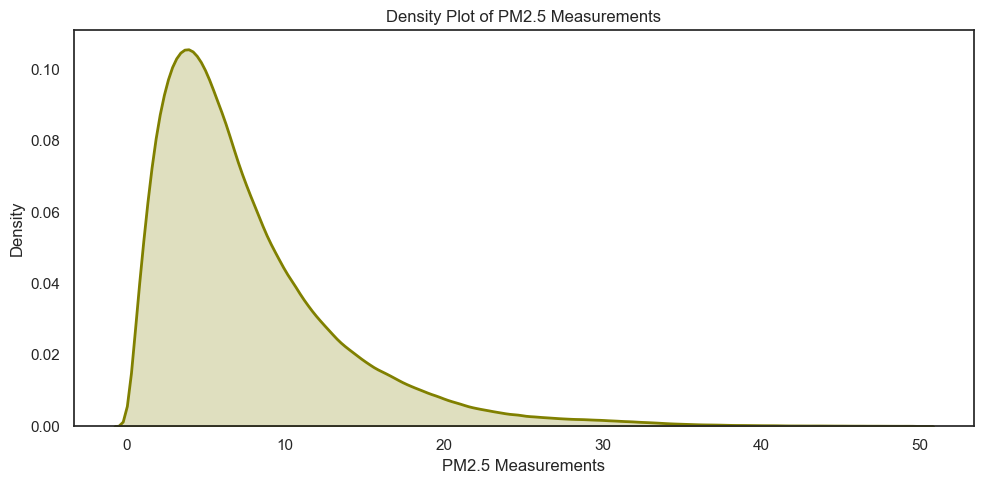

In [21]:
#Smaller density 
df_clean = df[df['PM25_ugm3'] <= 50].dropna()

plt.figure(figsize=(10,5))
sns.kdeplot(df_clean['PM25_ugm3'], fill=True, color='olive', linewidth=2)

plt.xlabel('PM2.5 Measurements')
plt.ylabel('Density')
plt.title('Density Plot of PM2.5 Measurements')

plt.tight_layout()
plt.show()

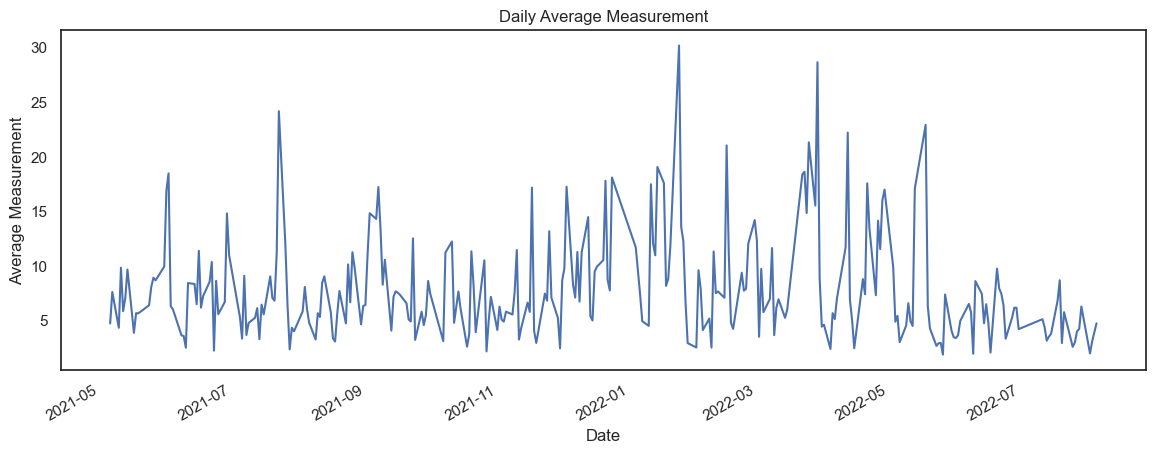

In [22]:
# Average measurement over time 
daily_avg = df_clean.groupby('date')['PM25_ugm3'].mean()
daily_avg.plot(figsize=(14,5))
plt.xlabel("Date")
plt.ylabel("Average Measurement")
plt.title("Daily Average Measurement")
plt.show()

Location

In [23]:
#Approximate km^2 area car drove around
lat_min = df['latitude'].min()
lat_max = df['latitude'].max()
lon_min = df['longitude'].min()
lon_max = df['longitude'].max()

# Very rough conversion is 1 degree lat/long approxes to 111km
# Approximate conversion
lat_km = (lat_max - lat_min) * 111
mean_lat = df['latitude'].mean()
lon_km = (lon_max - lon_min) * 111 * math.cos(math.radians(mean_lat)) #times the cos(lat)

# Approximate area
area_km2 = lat_km * lon_km

print(f"Approximate area covered by car: {area_km2:.2f} km²")

Approximate area covered by car: 195.66 km²


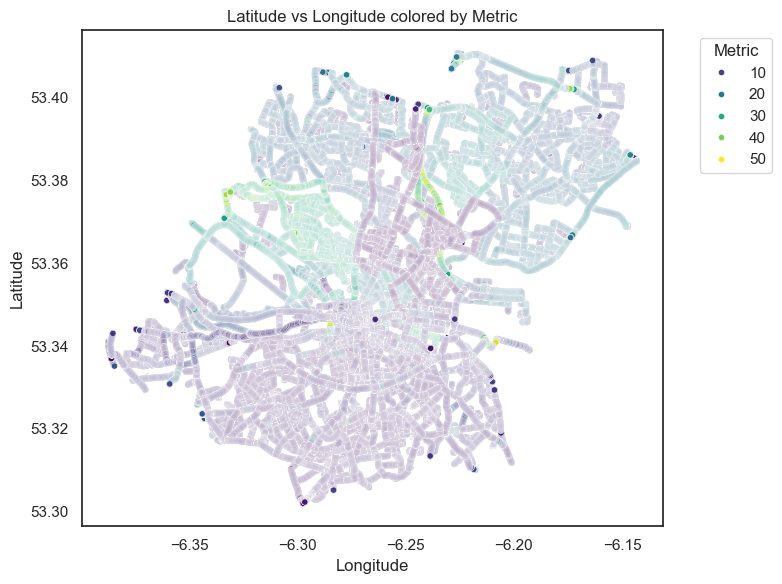

In [24]:
#lat/long by pm2.5

plt.figure(figsize=(8,6))
scatter = sns.scatterplot(
    x='longitude', 
    y='latitude', 
    hue='PM25_ugm3',       # color by recording
    palette='viridis',  # colormap palette
    data=df_clean,
    s=20               # size of points
)

plt.title("Latitude vs Longitude colored by Metric")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.2 Weather data understanding

In [25]:
# ==================================================
# 2.1 Weather data: loading and understanding
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# Load weather data
# -----------------------------
weather_path = Path().resolve().parent / "data" / "external" / "airport_weather.csv"

# The first 25 lines are metadata; the real header is on line 26
weather_df = pd.read_csv(weather_path, skiprows=25)

print("Weather data loaded.")
print(f"Shape: {weather_df.shape}")
display(weather_df.head())


# -----------------------------
# Basic structure checks
# -----------------------------
print("\nColumn names:")
print(weather_df.columns.tolist())

print("\nData types:")
print(weather_df.dtypes)

print("\nDuplicate rows:")
print(weather_df.duplicated().sum())


# -----------------------------
# Parse date column
# -----------------------------
weather_df["date"] = pd.to_datetime(
    weather_df["date"],
    format="%d-%b-%Y",
    errors="coerce"
)

print("\nMissing dates after parsing:")
print(weather_df["date"].isna().sum())


# -----------------------------
# Keep only project-relevant dates:
# May 2021 to August 2022
# -----------------------------
start_date = pd.Timestamp("2021-05-01")
end_date = pd.Timestamp("2022-08-31")

weather_filtered = weather_df[
    weather_df["date"].between(start_date, end_date)
].reset_index(drop=True)

print("\nFiltered to project-relevant period (May 2021 to August 2022).")
print(f"Shape: {weather_filtered.shape}")
display(weather_filtered.head())


# -----------------------------
# Remove unnecessary columns
# -----------------------------
cols_to_drop = [
    "ind", "ind.1", "igmin", "ind.2", "gmin", "ind.3", "ind.4", "ind.5", "dos", "smd_wd", "smd_md", "smd_pd", "cbl", "soil"
]

existing_drop_cols = [col for col in cols_to_drop if col in weather_filtered.columns]
weather_filtered = weather_filtered.drop(columns=existing_drop_cols)

print("\nDropped unnecessary columns:")
print(existing_drop_cols)

print("\nRemaining columns:")
print(weather_filtered.columns.tolist())


# -----------------------------
# Coerce remaining non-date columns to numeric where possible
# -----------------------------
for col in weather_filtered.columns:
    if col != "date":
        weather_filtered[col] = pd.to_numeric(weather_filtered[col], errors="coerce")


# -----------------------------
# Variable overview
# -----------------------------
print("\nSummary statistics (numeric variables):")
display(weather_filtered.describe())

print("\nNon-numeric columns:")
non_numeric_cols = weather_filtered.select_dtypes(exclude="number").columns.tolist()
print(non_numeric_cols)


# -----------------------------
# Time coverage
# -----------------------------
print("\nTime coverage:")
print(f"Start date: {weather_filtered['date'].min()}")
print(f"End date:   {weather_filtered['date'].max()}")
print(f"Number of unique dates: {weather_filtered['date'].nunique()}")


# -----------------------------
# Granularity check
# -----------------------------
date_dupes = weather_filtered.duplicated(subset=["date"]).sum()

print("\nGranularity check:")
print(f"Duplicate dates: {date_dupes}")

if date_dupes == 0:
    print("Granularity looks correct: one row per date.")
else:
    print("Warning: there are multiple rows for some dates.")


# -----------------------------
# Missingness
# -----------------------------
missing_summary = (
    weather_filtered.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(weather_filtered))
    .sort_values("n_missing", ascending=False)
)

print("\nMissingness summary:")
display(missing_summary)


# -----------------------------
# Candidate weather predictors
# -----------------------------
candidate_weather_vars = [
    "rain", "maxtp", "mintp", "wdsp", "hm", "hg", "sun", "g_rad", "pe", "evap"
]

existing_weather_vars = [col for col in candidate_weather_vars if col in weather_filtered.columns]

print("\nCandidate weather variables summary:")
display(weather_filtered[existing_weather_vars].describe())

Weather data loaded.
Shape: (30740, 26)


,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,hg,sun,dos,g_rad,soil,pe,evap,smd_wd,smd_md,smd_pd
0,01-jan-1942,0,9.7,0,6.8,0,4.7,2,0.0,1020.3,...,,0.0,0,,,1.1,1.4,,,
1,02-jan-1942,0,9.9,0,7.9,0,6.7,0,0.1,1016.2,...,,0.0,0,,,0.7,0.9,,,
2,03-jan-1942,0,11.2,0,8.9,0,7.2,0,1.5,1006.8,...,,0.1,0,,,0.5,0.6,,,
3,04-jan-1942,0,9.2,0,2.7,0,3.4,0,3.5,1001.5,...,,0.6,0,,,0.6,0.7,,,
4,05-jan-1942,0,3.5,1,-0.8,0,0.0,0,0.6,1013.4,...,,3.4,0,,,0.6,0.7,,,



Column names:
['date', 'ind', 'maxtp', 'ind.1', 'mintp', 'igmin', 'gmin', 'ind.2', 'rain', 'cbl', 'wdsp', 'ind.3', 'hm', 'ind.4', 'ddhm', 'ind.5', 'hg', 'sun', 'dos', 'g_rad', 'soil', 'pe', 'evap', 'smd_wd', 'smd_md', 'smd_pd']

Data types:
date       object
ind         int64
maxtp     float64
ind.1       int64
mintp     float64
igmin       int64
gmin       object
ind.2       int64
rain      float64
cbl       float64
wdsp      float64
ind.3       int64
hm         object
ind.4       int64
ddhm       object
ind.5       int64
hg         object
sun       float64
dos        object
g_rad      object
soil       object
pe        float64
evap       object
smd_wd     object
smd_md     object
smd_pd     object
dtype: object

Duplicate rows:
0

Missing dates after parsing:
0

Filtered to project-relevant period (May 2021 to August 2022).
Shape: (488, 26)


,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,hg,sun,dos,g_rad,soil,pe,evap,smd_wd,smd_md,smd_pd
0,2021-05-01,0,11.3,1,-1.9,1,-4.4,2,0.0,1008.3,...,12,7.6,0,1622,9.300,2.0,2.8,44.4,44.4,44.1
1,2021-05-02,0,12.9,0,2.0,1,-1.7,2,0.0,1008.7,...,16,7.5,0,1888,11.125,2.5,3.5,45.9,45.9,45.7
2,2021-05-03,0,12.5,0,5.1,0,2.1,0,10.2,991.5,...,38,2.4,0,1024,9.775,1.7,2.6,36.6,36.6,36.6
3,2021-05-04,0,10.1,0,2.6,0,3.9,0,1.3,992.0,...,36,8.0,0,1823,8.425,2.2,4.0,36.8,36.8,36.9
4,2021-05-05,0,10.6,0,0.3,0,0.5,0,2.7,1000.0,...,25,6.4,0,1588,7.775,1.9,2.9,35.4,35.4,35.6



Dropped unnecessary columns:
['ind', 'ind.1', 'igmin', 'ind.2', 'gmin', 'ind.3', 'ind.4', 'ind.5', 'dos', 'smd_wd', 'smd_md', 'smd_pd', 'cbl', 'soil']

Remaining columns:
['date', 'maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'ddhm', 'hg', 'sun', 'g_rad', 'pe', 'evap']

Summary statistics (numeric variables):


,date,maxtp,mintp,rain,wdsp,hm,ddhm,hg,sun,g_rad,pe,evap
count,488,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000
mean,2021-12-30 12:00:00,15.290574,7.069057,1.611066,8.550820,15.229508,207.479508,22.743852,4.629303,1188.885246,1.851025,2.605533
min,2021-05-01 00:00:00,3.800000,-4.400000,0.000000,2.600000,5.000000,0.000000,9.000000,0.000000,20.000000,0.000000,0.000000
25%,2021-08-30 18:00:00,11.400000,3.400000,0.000000,6.000000,11.000000,140.000000,17.000000,1.000000,476.250000,0.900000,1.200000
50%,2021-12-30 12:00:00,15.600000,7.600000,0.100000,8.000000,14.000000,250.000000,21.000000,4.000000,1119.000000,1.800000,2.500000
75%,2022-05-01 06:00:00,19.000000,10.525000,1.300000,10.525000,18.000000,280.000000,28.000000,7.300000,1764.500000,2.700000,3.900000
max,2022-08-31 00:00:00,29.100000,16.900000,26.900000,24.400000,39.000000,350.000000,54.000000,15.500000,2960.000000,4.600000,6.100000
std,NaN,4.926336,4.489628,3.580187,3.319688,5.307446,87.647790,7.910820,3.980649,763.301036,1.119364,1.597994



Non-numeric columns:
['date']

Time coverage:
Start date: 2021-05-01 00:00:00
End date:   2022-08-31 00:00:00
Number of unique dates: 488

Granularity check:
Duplicate dates: 0
Granularity looks correct: one row per date.

Missingness summary:


,n_missing,pct_missing
date,0,0.0
maxtp,0,0.0
mintp,0,0.0
rain,0,0.0
wdsp,0,0.0
hm,0,0.0
ddhm,0,0.0
hg,0,0.0
sun,0,0.0
g_rad,0,0.0



Candidate weather variables summary:


,rain,maxtp,mintp,wdsp,hm,hg,sun,g_rad,pe,evap
count,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000
mean,1.611066,15.290574,7.069057,8.550820,15.229508,22.743852,4.629303,1188.885246,1.851025,2.605533
std,3.580187,4.926336,4.489628,3.319688,5.307446,7.910820,3.980649,763.301036,1.119364,1.597994
min,0.000000,3.800000,-4.400000,2.600000,5.000000,9.000000,0.000000,20.000000,0.000000,0.000000
25%,0.000000,11.400000,3.400000,6.000000,11.000000,17.000000,1.000000,476.250000,0.900000,1.200000
50%,0.100000,15.600000,7.600000,8.000000,14.000000,21.000000,4.000000,1119.000000,1.800000,2.500000
75%,1.300000,19.000000,10.525000,10.525000,18.000000,28.000000,7.300000,1764.500000,2.700000,3.900000
max,26.900000,29.100000,16.900000,24.400000,39.000000,54.000000,15.500000,2960.000000,4.600000,6.100000


### 2.3 Traffic data understanding

In [26]:
# ==================================================
# 2.2 Traffic data: loading and understanding
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# Load traffic data
# -----------------------------
traffic_path = Path().resolve().parent / "data" / "external" / "traffic_daily_by_region_from_sites.csv"

traffic_df = pd.read_csv(traffic_path)

print("Traffic data loaded.")
print(f"Shape: {traffic_df.shape}")
display(traffic_df.head())


# -----------------------------
# Basic structure checks
# -----------------------------
print("\nColumn names:")
print(traffic_df.columns.tolist())

print("\nData types:")
print(traffic_df.dtypes)

print("\nDuplicate rows:")
print(traffic_df.duplicated().sum())


# -----------------------------
# Parse date column
# -----------------------------
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

print("\nMissing dates after parsing:")
print(traffic_df["date"].isna().sum())


# -----------------------------
# Variable overview
# -----------------------------
print("\nSummary statistics (numeric variables):")
display(traffic_df.describe())

print("\nUnique regions:")
print(sorted(traffic_df["Region"].dropna().unique()))
print(f"Number of unique regions: {traffic_df['Region'].nunique()}")


# -----------------------------
# Time coverage
# -----------------------------
print("\nTime coverage:")
print(f"Start date: {traffic_df['date'].min()}")
print(f"End date:   {traffic_df['date'].max()}")
print(f"Number of unique dates: {traffic_df['date'].nunique()}")


# -----------------------------
# Granularity check
# -----------------------------
region_day_dupes = traffic_df.duplicated(subset=["date", "Region"]).sum()

print("\nGranularity check:")
print(f"Duplicate date-region pairs: {region_day_dupes}")

if region_day_dupes == 0:
    print("Granularity looks correct: one row per day per region.")
else:
    print("Warning: there are multiple rows for some day-region pairs.")


# -----------------------------
# Missingness
# -----------------------------
missing_summary = (
    traffic_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(traffic_df))
    .sort_values("n_missing", ascending=False)
)

print("\nMissingness summary:")
display(missing_summary)


# -----------------------------
# Quick understanding of key variables
# -----------------------------
key_vars = [
    "mean_daily_site_volume",
    "median_daily_site_volume",
    "total_daily_site_volume",
    "n_sites"
]

existing_key_vars = [col for col in key_vars if col in traffic_df.columns]

print("\nKey traffic variables summary:")
display(traffic_df[existing_key_vars].describe())


# -----------------------------
# Region-level coverage snapshot
# -----------------------------
region_summary = (
    traffic_df.groupby("Region", as_index=False)
    .agg(
        n_days=("date", "nunique"),
        mean_traffic=("mean_daily_site_volume", "mean"),
        mean_sites=("n_sites", "mean")
    )
    .sort_values("Region")
)

print("\nRegion-level summary:")
display(region_summary)


Traffic data loaded.
Shape: (3416, 6)


,date,Region,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
0,2021-05-01,CCITY,12098.288136,10559.5,1427598,118
1,2021-05-01,DCC1,17020.015152,14865.5,1123321,66
2,2021-05-01,IRE,16739.429319,14867.0,3197231,191
3,2021-05-01,IRE3,18313.857143,17985.0,512788,28
4,2021-05-01,NCITY,14283.241026,14182.0,2785232,195



Column names:
['date', 'Region', 'mean_daily_site_volume', 'median_daily_site_volume', 'total_daily_site_volume', 'n_sites']

Data types:
date                         object
Region                       object
mean_daily_site_volume      float64
median_daily_site_volume    float64
total_daily_site_volume       int64
n_sites                       int64
dtype: object

Duplicate rows:
0

Missing dates after parsing:
0

Summary statistics (numeric variables):


,date,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
count,3416,3416.000000,3416.000000,3.416000e+03,3416.000000
mean,2021-12-30 11:59:59.999999744,17305.512849,15798.784251,2.127190e+06,125.476874
min,2021-05-01 00:00:00,385.533333,296.000000,1.181500e+04,1.000000
25%,2021-08-30 18:00:00,15420.018133,14394.750000,1.519529e+06,69.000000
50%,2021-12-30 12:00:00,17091.416667,15794.500000,2.002592e+06,120.000000
75%,2022-05-01 06:00:00,19196.939659,17343.375000,2.959881e+06,193.000000
max,2022-08-31 00:00:00,29575.000000,29575.000000,4.449082e+06,211.000000
std,NaN,3057.349864,2575.027451,1.055490e+06,58.852308



Unique regions:
['CCITY', 'DCC1', 'IRE', 'IRE3', 'NCITY', 'SCITY', 'WCITY1']
Number of unique regions: 7

Time coverage:
Start date: 2021-05-01 00:00:00
End date:   2022-08-31 00:00:00
Number of unique dates: 488

Granularity check:
Duplicate date-region pairs: 0
Granularity looks correct: one row per day per region.

Missingness summary:


,n_missing,pct_missing
date,0,0.0
Region,0,0.0
mean_daily_site_volume,0,0.0
median_daily_site_volume,0,0.0
total_daily_site_volume,0,0.0
n_sites,0,0.0



Key traffic variables summary:


,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
count,3416.000000,3416.000000,3.416000e+03,3416.000000
mean,17305.512849,15798.784251,2.127190e+06,125.476874
std,3057.349864,2575.027451,1.055490e+06,58.852308
min,385.533333,296.000000,1.181500e+04,1.000000
25%,15420.018133,14394.750000,1.519529e+06,69.000000
50%,17091.416667,15794.500000,2.002592e+06,120.000000
75%,19196.939659,17343.375000,2.959881e+06,193.000000
max,29575.000000,29575.000000,4.449082e+06,211.000000



Region-level summary:


,Region,n_days,mean_traffic,mean_sites
0,CCITY,488,15992.524043,119.131148
1,DCC1,488,21158.914809,68.147541
2,IRE,488,18994.340880,196.782787
3,IRE3,488,18285.388752,27.432377
4,NCITY,488,16510.997807,199.520492
5,SCITY,488,14229.644722,147.706967
6,WCITY1,488,15966.778928,119.616803


## 3. Data aggregation & preparation

### 3.1 Aggregate mobile PM2.5 measurements to a Dublin-day target

In [27]:
# ==================================================
# Air quality data: Step 2
# Aggregate mobile PM2.5 measurements to a Dublin-day target
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# 0. File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "raw" / "AirView_DublinCity_Measurements_ugm3.csv"

output_path = project_root / "data" / "raw" / "air_quality_daily_dublin_avg_pm25.csv"

# -----------------------------
# 1. Load only needed columns
# -----------------------------
air_df = pd.read_csv(
    air_path,
    usecols=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"]
)

print("\nRaw air quality data shape:")
print(air_df.shape)
display(air_df.head())


# -----------------------------
# 2. Basic cleaning
# -----------------------------
air_df["gps_timestamp"] = pd.to_datetime(
    air_df["gps_timestamp"],
    errors="coerce",
    utc=True
)

air_df = air_df[air_df["PM25_ugm3"] <= 400] #assume measurement errors

air_df = air_df.dropna(subset=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"])

print("\nShape after basic cleaning:")
print(air_df.shape)


# -----------------------------
# 3. Aggregate over time
# -----------------------------
# Convert timestamp to calendar day
air_df["date"] = air_df["gps_timestamp"].dt.date


# -----------------------------
# 4. Aggregate over location
# -----------------------------
# Decision:
# For each day, pool PM2.5 observations across all recorded Dublin locations
# and compute one Dublin-wide daily average PM2.5 value.

# Create an approximate location identifier for transparency
air_df["location_id"] = (
    air_df["latitude"].round(5).astype(str) + "_" +
    air_df["longitude"].round(5).astype(str)
)

air_daily = (
    air_df.groupby("date", as_index=False)
    .agg(
        dublin_daily_avg_pm25=("PM25_ugm3", "mean"),
        pm25_count=("PM25_ugm3", "size"),
        pm25_min=("PM25_ugm3", "min"),
        pm25_max=("PM25_ugm3", "max"),
        n_unique_locations=("location_id", "nunique")
    )
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nFinal aggregated dataset shape:")
print(air_daily.shape)

display(air_daily.head())


# -----------------------------
# 5. Save output
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
air_daily.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")


Raw air quality data shape:
(5030143, 4)


,gps_timestamp,latitude,longitude,PM25_ugm3
0,2022-04-07 14:56:36 UTC,53.346434,-6.263997,4.927
1,2022-04-07 14:56:37 UTC,53.346434,-6.263997,4.240
2,2022-04-07 14:56:38 UTC,53.346434,-6.263997,4.204
3,2022-04-07 14:56:39 UTC,53.346434,-6.263997,3.410
4,2022-04-07 14:56:40 UTC,53.346434,-6.263997,4.003



Shape after basic cleaning:
(4940149, 4)

Final aggregated dataset shape:
(286, 6)


,date,dublin_daily_avg_pm25,pm25_count,pm25_min,pm25_max,n_unique_locations
0,2021-05-06,4.903776,7518,0.702,107.655,5684
1,2021-05-07,7.940760,13204,1.023,289.730,7900
2,2021-05-10,4.443267,1566,0.195,101.522,1112
3,2021-05-11,9.881657,2964,3.730,69.970,1764
4,2021-05-12,5.863840,650,0.596,31.540,522



Saved aggregated daily air quality data to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/raw/air_quality_daily_dublin_avg_pm25.csv


#### 3.1.1 By Location

In [28]:
# ==================================================
# Air quality data: Step 2.1 (by location)
# Aggregate mobile PM2.5 measurements to Dublin location
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# 0. File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "raw" / "AirView_DublinCity_Measurements_ugm3.csv"

output_path = project_root / "data" / "processed" / "location_air_quality_daily_dublin_avg_pm25.csv"

# -----------------------------
# 1. Load only needed columns
# -----------------------------
air_df = pd.read_csv(
    air_path,
    usecols=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"]
)

# -----------------------------
# 2. Basic cleaning
# -----------------------------
air_df["gps_timestamp"] = pd.to_datetime(
    air_df["gps_timestamp"],
    errors="coerce",
    utc=True
)

air_df = air_df[air_df["PM25_ugm3"] <= 400] #assume measurement errors

air_df = air_df.dropna(subset=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"])

# -----------------------------
# 3. Aggregate over time
# -----------------------------
# Convert timestamp to calendar day
air_df["date"] = air_df["gps_timestamp"].dt.date

# -----------------------------
# 4. Aggregate over location
        # North or South of Liffey
# -----------------------------
# Decision: Based on location being north or south of the Liffey River 

# Liffey latitude
liffey_lat = 53.346565

# Mask north and south locations
north_loc = air_df['latitude'] > liffey_lat
south_loc = air_df['latitude'] < liffey_lat

# Create series
location_label = pd.Series(index=air_df.index, dtype=str)

location_label[north_loc] = 'north'
location_label[south_loc] = 'south'

# Assign back to dataframe
air_df['location_label'] = location_label

# Group by date and location label
air_daily_loc = (
    air_df.groupby(["date", "location_label"], as_index=False)
    .agg(
        dublin_daily_avg_pm25=("PM25_ugm3", "mean"),
        pm25_count=("PM25_ugm3", "size"),
        pm25_min=("PM25_ugm3", "min"),
        pm25_max=("PM25_ugm3", "max")
    )
    .sort_values(["date", "location_label"])
    .reset_index(drop=True)
)

print("\nFinal aggregated dataset shape:")
print(air_daily_loc.shape)

display(air_daily_loc.head())

# -----------------------------
# 5. Save output
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
air_daily_loc.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")


Final aggregated dataset shape:
(534, 6)


,date,location_label,dublin_daily_avg_pm25,pm25_count,pm25_min,pm25_max
0,2021-05-06,north,8.427493,71,3.963,17.017
1,2021-05-06,south,4.870181,7447,0.702,107.655
2,2021-05-07,north,7.304802,6264,1.023,142.365
3,2021-05-07,south,8.514772,6940,1.356,289.730
4,2021-05-10,south,4.443267,1566,0.195,101.522



Saved aggregated daily air quality data to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/location_air_quality_daily_dublin_avg_pm25.csv


### 3.2 Aggregate traffic measurements to a Dublin-day target

In [29]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

traffic_path = project_root / "data" / "external" / "traffic_daily_by_region_from_sites.csv"
traffic_output_path = project_root / "data" / "processed" / "traffic_daily_dublin_avg.csv"

# -----------------------------
# Load traffic data
# -----------------------------
traffic_df = pd.read_csv(traffic_path)
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

print("Raw traffic shape (region-day level):")
print(traffic_df.shape)
display(traffic_df.head())

# -----------------------------
# Aggregate from region-day to Dublin-day
# -----------------------------
# Decision:
# The PM2.5 target is a Dublin-wide daily average.
# To align traffic to that same spatial unit, aggregate region-level traffic
# to one Dublin-wide traffic summary per day.

traffic_dublin_daily = (
    traffic_df
    .groupby("date", as_index=False)
    .agg(
        dublin_daily_mean_site_traffic=("mean_daily_site_volume", "mean"),
        dublin_daily_median_site_traffic=("median_daily_site_volume", "mean"),
        dublin_daily_total_traffic=("total_daily_site_volume", "sum"),
        dublin_daily_n_sites=("n_sites", "sum"),
        dublin_daily_n_regions=("Region", "nunique")
    )
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nTraffic shape after spatial aggregation to Dublin-day:")
print(traffic_dublin_daily.shape)
display(traffic_dublin_daily.head())

# -----------------------------
# Save processed Dublin-level traffic data
# -----------------------------
traffic_output_path.parent.mkdir(parents=True, exist_ok=True)
traffic_dublin_daily.to_csv(traffic_output_path, index=False)

print(f"\nSaved processed traffic data to:\n{traffic_output_path}")

Raw traffic shape (region-day level):
(3416, 6)


,date,Region,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
0,2021-05-01,CCITY,12098.288136,10559.5,1427598,118
1,2021-05-01,DCC1,17020.015152,14865.5,1123321,66
2,2021-05-01,IRE,16739.429319,14867.0,3197231,191
3,2021-05-01,IRE3,18313.857143,17985.0,512788,28
4,2021-05-01,NCITY,14283.241026,14182.0,2785232,195



Traffic shape after spatial aggregation to Dublin-day:
(488, 6)


,date,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_n_sites,dublin_daily_n_regions
0,2021-05-01,14966.243226,14037.571429,12507607,864,7
1,2021-05-02,12794.240957,11572.857143,10665395,864,7
2,2021-05-03,11436.567791,10586.285714,9516882,863,7
3,2021-05-04,16300.696407,15371.500000,13630512,863,7
4,2021-05-05,16559.577491,15467.285714,13936738,863,7



Saved processed traffic data to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/traffic_daily_dublin_avg.csv


#### 3.2.1 By location

In [30]:
# ==================================================
# Traffic data (by location)
# Aggregate traffic patterns by location
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

traffic_path = project_root / "data" / "external" / "traffic_daily_by_region_from_sites.csv"

output_path = project_root / "data" / "processed" / "traffic_daily_location_avg.csv"

# -----------------------------
# Load traffic data
# -----------------------------
traffic_df = pd.read_csv(traffic_path)
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

# -----------------------------
# Aggregate by NCITY and SCITY
# -----------------------------
n_s_city = (traffic_df['Region'] == 'NCITY') | (traffic_df['Region'] == 'SCITY')

traffic_location_daily = traffic_df[n_s_city].reset_index(drop=True)

traffic_location_daily = traffic_location_daily.rename(columns={'Region': 'location_label'})

traffic_location_daily['location_label'] = traffic_location_daily['location_label'].map({
    'NCITY': 'north',
    'SCITY': 'south'
})

print("\nTraffic shape after aggregation by location:")
print(traffic_location_daily.shape)
display(traffic_location_daily.head())

# -----------------------------
# Save processed Dublin-level traffic data by location
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
traffic_location_daily.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")


Traffic shape after aggregation by location:
(976, 6)


,date,location_label,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
0,2021-05-01,north,14283.241026,14182.0,2785232,195
1,2021-05-01,south,11706.630137,11797.5,1709168,146
2,2021-05-02,north,12075.846154,11878.0,2354790,195
3,2021-05-02,south,10177.287671,10322.5,1485884,146
4,2021-05-03,north,11044.369231,11106.0,2153652,195



Saved aggregated daily air quality data to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/traffic_daily_location_avg.csv


### 3.3 Preparing weather measurements

In [31]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

weather_path = project_root / "data" / "external" / "airport_weather.csv"
weather_output_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"

# -----------------------------
# Load raw weather data
# -----------------------------
weather_df = pd.read_csv(weather_path, skiprows=25)

weather_df["date"] = pd.to_datetime(
    weather_df["date"],
    format="%d-%b-%Y",
    errors="coerce"
)

print("Raw weather shape:")
print(weather_df.shape)
display(weather_df.head())

# -----------------------------
# Keep only project period
# -----------------------------
start_date = pd.Timestamp("2021-05-01")
end_date = pd.Timestamp("2022-08-31")

weather_df = weather_df[weather_df["date"].between(start_date, end_date)].copy()

# -----------------------------
# Drop unnecessary columns
# -----------------------------
cols_to_drop = [
    "ind", "ind.1", "igmin", "ind.2", "gmin", "ind.3", "ind.4",
    "ddhm", "ind.5", "dos", "smd_wd", "smd_md", "smd_pd", "cbl", "soil"
]
existing_drop_cols = [col for col in cols_to_drop if col in weather_df.columns]
weather_df = weather_df.drop(columns=existing_drop_cols)

# -----------------------------
# Coerce non-date columns to numeric
# -----------------------------
for col in weather_df.columns:
    if col != "date":
        weather_df[col] = pd.to_numeric(weather_df[col], errors="coerce")

# -----------------------------
# Keep one row per date
# -----------------------------
weather_daily = (
    weather_df
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nPrepared weather shape:")
print(weather_daily.shape)
display(weather_daily.head())

print("\nDuplicate dates:")
print(weather_daily.duplicated(subset=["date"]).sum())

# -----------------------------
# Save prepared weather data
# -----------------------------
weather_output_path.parent.mkdir(parents=True, exist_ok=True)
weather_daily.to_csv(weather_output_path, index=False)

print(f"\nSaved prepared weather data to:\n{weather_output_path}")

Raw weather shape:
(30740, 26)


,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,hg,sun,dos,g_rad,soil,pe,evap,smd_wd,smd_md,smd_pd
0,1942-01-01,0,9.7,0,6.8,0,4.7,2,0.0,1020.3,...,,0.0,0,,,1.1,1.4,,,
1,1942-01-02,0,9.9,0,7.9,0,6.7,0,0.1,1016.2,...,,0.0,0,,,0.7,0.9,,,
2,1942-01-03,0,11.2,0,8.9,0,7.2,0,1.5,1006.8,...,,0.1,0,,,0.5,0.6,,,
3,1942-01-04,0,9.2,0,2.7,0,3.4,0,3.5,1001.5,...,,0.6,0,,,0.6,0.7,,,
4,1942-01-05,0,3.5,1,-0.8,0,0.0,0,0.6,1013.4,...,,3.4,0,,,0.6,0.7,,,



Prepared weather shape:
(488, 11)


,date,maxtp,mintp,rain,wdsp,hm,hg,sun,g_rad,pe,evap
0,2021-05-01,11.3,-1.9,0.0,4.8,7,12,7.6,1622,2.0,2.8
1,2021-05-02,12.9,2.0,0.0,5.4,12,16,7.5,1888,2.5,3.5
2,2021-05-03,12.5,5.1,10.2,13.6,27,38,2.4,1024,1.7,2.6
3,2021-05-04,10.1,2.6,1.3,18.5,27,36,8.0,1823,2.2,4.0
4,2021-05-05,10.6,0.3,2.7,8.7,16,25,6.4,1588,1.9,2.9



Duplicate dates:
0

Saved prepared weather data to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/weather_daily_prepared.csv


## 4. Data merging

### 4.1 Overall merge

In [32]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "processed" / "air_quality_daily_dublin_avg_pm25.csv"
weather_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"
traffic_path = project_root / "data" / "processed" / "traffic_daily_dublin_avg.csv"

output_path = project_root / "data" / "processed" / "merged_daily_dublin_avg_pm25_weather_traffic.csv"

# -----------------------------
# Load prepared datasets
# -----------------------------
air_df = pd.read_csv(air_path)
weather_daily = pd.read_csv(weather_path)
traffic_dublin_daily = pd.read_csv(traffic_path)

air_df["date"] = pd.to_datetime(air_df["date"], errors="coerce")
weather_daily["date"] = pd.to_datetime(weather_daily["date"], errors="coerce")
traffic_dublin_daily["date"] = pd.to_datetime(traffic_dublin_daily["date"], errors="coerce")

print("Air quality shape:")
print(air_df.shape)

print("\nWeather shape:")
print(weather_daily.shape)

print("\nTraffic shape:")
print(traffic_dublin_daily.shape)

# -----------------------------
# Merge datasets
# -----------------------------
merged_df = (
    air_df
    .merge(weather_daily, on="date", how="left")
    .merge(traffic_dublin_daily, on="date", how="left")
    .sort_values("date")
    .reset_index(drop=True)
)

# -----------------------------
# Add calendar features
# -----------------------------
merged_df["day_name"] = merged_df["date"].dt.day_name()
merged_df["day_of_week"] = merged_df["date"].dt.dayofweek
merged_df["is_weekend"] = merged_df["day_of_week"].isin([5, 6]).astype(int)

# Move key variables to the front
front_cols = [
    "date",
    "day_name",
    "day_of_week",
    "is_weekend",
    "dublin_daily_avg_pm25",
    "pm25_count",
    "n_unique_locations",
    "pm25_min",
    "pm25_max"
]
remaining_cols = [col for col in merged_df.columns if col not in front_cols]
merged_df = merged_df[front_cols + remaining_cols]

# -----------------------------
# Basic structure checks
# -----------------------------
print("\nMerged dataset shape:")
print(merged_df.shape)

print("\nColumns:")
print(merged_df.columns.tolist())

print("\nData types:")
print(merged_df.dtypes)

print("\nDuplicate dates:")
print(merged_df.duplicated(subset=["date"]).sum())

print("\nDate range:")
print(f"Start: {merged_df['date'].min()}")
print(f"End:   {merged_df['date'].max()}")

print("\nMissingness summary:")
missing_summary = (
    merged_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(merged_df))
    .sort_values("n_missing", ascending=False)
)
display(missing_summary)

print("\nNumeric summary:")
display(merged_df.describe())

print("\nHead of merged dataset:")
display(merged_df.head())

# -----------------------------
# Save merged dataset
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
merged_df.to_csv(output_path, index=False)

print(f"\nSaved merged dataset to:\n{output_path}")

Air quality shape:
(286, 6)

Weather shape:
(488, 11)

Traffic shape:
(488, 6)

Merged dataset shape:
(286, 24)

Columns:
['date', 'day_name', 'day_of_week', 'is_weekend', 'dublin_daily_avg_pm25', 'pm25_count', 'n_unique_locations', 'pm25_min', 'pm25_max', 'maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap', 'dublin_daily_mean_site_traffic', 'dublin_daily_median_site_traffic', 'dublin_daily_total_traffic', 'dublin_daily_n_sites', 'dublin_daily_n_regions']

Data types:
date                                datetime64[ns]
day_name                                    object
day_of_week                                  int32
is_weekend                                   int64
dublin_daily_avg_pm25                      float64
pm25_count                                   int64
n_unique_locations                           int64
pm25_min                                   float64
pm25_max                                   float64
maxtp                                      fl

,n_missing,pct_missing
date,0,0.0
day_name,0,0.0
dublin_daily_n_sites,0,0.0
dublin_daily_total_traffic,0,0.0
dublin_daily_median_site_traffic,0,0.0
dublin_daily_mean_site_traffic,0,0.0
evap,0,0.0
pe,0,0.0
g_rad,0,0.0
sun,0,0.0



Numeric summary:


,date,day_of_week,is_weekend,dublin_daily_avg_pm25,pm25_count,n_unique_locations,pm25_min,pm25_max,maxtp,mintp,...,hg,sun,g_rad,pe,evap,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_n_sites,dublin_daily_n_regions
count,286,286.000000,286.0,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,...,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,2.860000e+02,286.000000,286.0
mean,2021-12-15 14:00:50.349650432,2.045455,0.0,8.095203,17273.657343,11078.629371,1.884619,247.381017,15.090909,6.919580,...,22.783217,4.528671,1172.664336,1.816434,2.562937,18307.139244,16749.672078,1.578613e+07,878.548951,7.0
min,2021-05-06 00:00:00,0.000000,0.0,1.925949,593.000000,203.000000,0.071000,23.215000,3.800000,-4.400000,...,9.000000,0.000000,50.000000,0.100000,0.100000,14793.572897,11461.428571,1.184910e+07,616.000000,7.0
25%,2021-08-24 06:00:00,1.000000,0.0,4.821168,13266.750000,8246.250000,0.407000,110.976000,11.125000,3.300000,...,17.000000,0.900000,460.000000,0.800000,1.100000,17793.585619,16181.142857,1.530086e+07,869.000000,7.0
50%,2021-12-09 12:00:00,2.000000,0.0,6.902611,18944.000000,11927.000000,0.824000,171.029000,15.600000,7.400000,...,21.500000,3.950000,1108.000000,1.800000,2.450000,18296.900762,16785.285714,1.576198e+07,880.500000,7.0
75%,2022-04-06 18:00:00,3.000000,0.0,9.925712,21743.250000,14375.000000,2.370250,287.372000,18.775000,10.375000,...,27.750000,7.250000,1781.250000,2.700000,3.800000,18973.427798,17428.785714,1.649859e+07,890.000000,7.0
max,2022-08-05 00:00:00,4.000000,0.0,30.384439,36847.000000,23694.000000,17.790000,1960.163000,29.100000,16.900000,...,54.000000,15.500000,2960.000000,4.500000,5.900000,20998.187277,19600.142857,1.759565e+07,917.000000,7.0
std,NaN,1.377016,0.0,4.766350,6071.516971,4522.050498,2.559029,243.924062,4.871844,4.498113,...,7.758766,3.941024,768.207661,1.124610,1.613699,962.354072,999.255732,9.109622e+05,24.444051,0.0



Head of merged dataset:


,date,day_name,day_of_week,is_weekend,dublin_daily_avg_pm25,pm25_count,n_unique_locations,pm25_min,pm25_max,maxtp,...,hg,sun,g_rad,pe,evap,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_n_sites,dublin_daily_n_regions
0,2021-05-06,Thursday,3,0,4.903776,7518,5684,0.702,107.655,12.0,...,26,12.1,2489,2.8,4.4,17149.593217,16134.928571,14458493,865,7
1,2021-05-07,Friday,4,0,8.028253,13206,7902,1.023,764.816,11.1,...,21,11.3,2394,2.7,4.1,17920.225608,17037.785714,15133373,866,7
2,2021-05-10,Monday,0,0,4.443267,1566,1112,0.195,101.522,15.3,...,27,2.6,1312,2.4,3.5,16803.592495,15754.428571,14089843,864,7
3,2021-05-11,Tuesday,1,0,9.881657,2964,1764,3.730,69.970,14.1,...,23,13.0,2716,2.9,4.7,17419.522593,16005.642857,14678272,866,7
4,2021-05-12,Wednesday,2,0,5.863840,650,522,0.596,31.540,12.3,...,16,3.2,1620,1.9,2.8,17497.224895,16398.214286,14770830,865,7



Saved merged dataset to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/merged_daily_dublin_avg_pm25_weather_traffic.csv


### 4.2 Merge by Location and Date

In [33]:
# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "processed" / "location_air_quality_daily_dublin_avg_pm25.csv"
weather_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"
traffic_path = project_root / "data" / "processed" / "traffic_daily_location_avg.csv"

output_path = project_root / "data" / "processed" / "location_merged_daily_dublin_avg_pm25_weather_traffic.csv"

# -----------------------------
# Load prepared datasets
# -----------------------------
weather_daily = pd.read_csv(weather_path)
air_daily_loc = pd.read_csv(air_path)
traffic_daily_loc = pd.read_csv(traffic_path)

# Standardize date
air_daily_loc["date"] = pd.to_datetime(air_daily_loc["date"], errors="coerce")
weather_daily["date"] = pd.to_datetime(weather_daily["date"], errors="coerce")
traffic_daily_loc["date"] = pd.to_datetime(traffic_daily_loc["date"], errors="coerce")

print("Air quality shape:")
print(air_daily_loc.shape)

print("\nWeather shape:")
print(weather_daily.shape)

print("\nTraffic shape:")
print(traffic_daily_loc.shape)

# -----------------------------
# Merge datasets
# -----------------------------
# Merging data with north and south city information
merged_location_df = (
    air_daily_loc
    .merge(weather_daily, on="date", how="left")
    .merge(traffic_daily_loc, on=["date", "location_label"], how="left")
    .sort_values(["date", "location_label"])
    .reset_index(drop=True)
)

# -----------------------------
# Add calendar features
# -----------------------------
merged_location_df["day_name"] = merged_location_df["date"].dt.day_name()
merged_location_df["day_of_week"] = merged_location_df["date"].dt.dayofweek
merged_location_df["is_weekend"] = merged_location_df["day_of_week"].isin([5, 6]).astype(int)

# Move key variables to the front
front_cols = [
    "date",
    "day_name",
    "day_of_week",
    "is_weekend",
    "location_label",
    "dublin_daily_avg_pm25",
    "pm25_count",
    "pm25_min",
    "pm25_max"
]
remaining_cols = [col for col in merged_location_df.columns if col not in front_cols]
merged_location_df = merged_location_df[front_cols + remaining_cols]

# -----------------------------
# Basic structure checks
# -----------------------------
print("\nMerged dataset shape:")
print(merged_location_df.shape)

print("\nColumns:")
print(merged_location_df.columns.tolist())

print("\nData types:")
print(merged_location_df.dtypes)

print("\nDuplicate dates:")
print(merged_location_df.duplicated(subset=["date"]).sum())

print("\nDate range:")
print(f"Start: {merged_location_df['date'].min()}")
print(f"End:   {merged_location_df['date'].max()}")

print("\nMissingness summary:")
missing_summary = (
    merged_location_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(merged_location_df))
    .sort_values("n_missing", ascending=False)
)
display(missing_summary)

print("\nNumeric summary:")
display(merged_location_df.describe())

print("\nHead of merged dataset:")
display(merged_location_df.head())

# -----------------------------
# Save merged dataset
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
merged_location_df.to_csv(output_path, index=False)

print(f"\nSaved merged dataset to:\n{output_path}")

Air quality shape:
(534, 6)

Weather shape:
(488, 11)

Traffic shape:
(976, 6)

Merged dataset shape:
(534, 23)

Columns:
['date', 'day_name', 'day_of_week', 'is_weekend', 'location_label', 'dublin_daily_avg_pm25', 'pm25_count', 'pm25_min', 'pm25_max', 'maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap', 'mean_daily_site_volume', 'median_daily_site_volume', 'total_daily_site_volume', 'n_sites']

Data types:
date                        datetime64[ns]
day_name                            object
day_of_week                          int32
is_weekend                           int64
location_label                      object
dublin_daily_avg_pm25              float64
pm25_count                           int64
pm25_min                           float64
pm25_max                           float64
maxtp                              float64
mintp                              float64
rain                               float64
wdsp                               float64
hm     

,n_missing,pct_missing
date,0,0.0
wdsp,0,0.0
total_daily_site_volume,0,0.0
median_daily_site_volume,0,0.0
mean_daily_site_volume,0,0.0
evap,0,0.0
pe,0,0.0
g_rad,0,0.0
sun,0,0.0
hg,0,0.0



Numeric summary:


,date,day_of_week,is_weekend,dublin_daily_avg_pm25,pm25_count,pm25_min,pm25_max,maxtp,mintp,rain,...,hm,hg,sun,g_rad,pe,evap,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
count,534,534.000000,534.0,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,...,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,5.340000e+02,534.000000
mean,2021-12-15 07:08:45.842696448,2.035581,0.0,8.505879,9251.215356,2.407858,137.761908,15.164232,6.994569,1.372285,...,15.294007,22.737828,4.555618,1173.780899,1.816667,2.561610,16189.368254,15764.144195,2.809853e+06,171.749064
min,2021-05-06 00:00:00,0.000000,0.0,1.453694,14.000000,0.071000,4.300000,3.800000,-4.400000,0.000000,...,6.000000,9.000000,0.000000,50.000000,0.100000,0.100000,11678.500000,10050.500000,1.728418e+06,113.000000
25%,2021-08-25 00:00:00,1.000000,0.0,4.996782,1239.250000,0.595250,54.159250,11.200000,3.300000,0.000000,...,11.000000,17.000000,0.900000,479.000000,0.800000,1.100000,14943.774011,15178.125000,2.212638e+06,148.000000
50%,2021-12-08 00:00:00,2.000000,0.0,7.301144,8727.500000,1.276500,111.021000,15.700000,7.600000,0.100000,...,14.000000,21.000000,4.000000,1099.000000,1.750000,2.400000,16284.053115,15811.750000,2.455320e+06,150.000000
75%,2022-04-06 18:00:00,3.000000,0.0,10.775947,16122.500000,3.112500,196.438000,18.775000,10.400000,1.175000,...,18.000000,27.000000,7.300000,1784.000000,2.700000,3.875000,17379.870647,16404.000000,3.467868e+06,200.000000
max,2022-08-05 00:00:00,4.000000,0.0,30.677423,26224.000000,20.544000,399.148000,29.100000,16.900000,26.900000,...,39.000000,54.000000,15.500000,2960.000000,4.500000,5.900000,21367.072581,20221.000000,3.835536e+06,211.000000
std,NaN,1.383584,0.0,5.016312,7789.303842,2.956234,102.352195,4.860911,4.488776,3.230295,...,5.223493,7.809805,3.949873,765.679677,1.124719,1.611348,1491.863420,1015.818590,6.455842e+05,26.404288



Head of merged dataset:


,date,day_name,day_of_week,is_weekend,location_label,dublin_daily_avg_pm25,pm25_count,pm25_min,pm25_max,maxtp,...,hm,hg,sun,g_rad,pe,evap,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
0,2021-05-06,Thursday,3,0,north,8.427493,71,3.963,17.017,12.0,...,18,26,12.1,2489,2.8,4.4,16539.630769,15709.0,3225228,195
1,2021-05-06,Thursday,3,0,south,4.870181,7447,0.702,107.655,12.0,...,18,26,12.1,2489,2.8,4.4,13485.904762,14266.0,1982428,147
2,2021-05-07,Friday,4,0,north,7.304802,6264,1.023,142.365,11.1,...,15,21,11.3,2394,2.7,4.1,17299.764103,16766.0,3373454,195
3,2021-05-07,Friday,4,0,south,8.514772,6940,1.356,289.730,11.1,...,15,21,11.3,2394,2.7,4.1,14254.727891,15226.0,2095445,147
4,2021-05-10,Monday,0,0,south,4.443267,1566,0.195,101.522,15.3,...,19,27,2.6,1312,2.4,3.5,13311.061644,14123.0,1943415,146



Saved merged dataset to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/location_merged_daily_dublin_avg_pm25_weather_traffic.csv


## 5. Merged data limitations

### 5.1 All-Dublin

Weekends are structurally outside the Air View observational design, so continuity is assessed against an expected weekday-only sequence rather than the full calendar.

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DATA_DIR = Path('../data/processed')
ALL_DUBLIN_PATH = DATA_DIR / 'merged_daily_dublin_avg_pm25_weather_traffic.csv'
NORTH_SOUTH_PATH = DATA_DIR / 'location_merged_daily_dublin_avg_pm25_weather_traffic.csv'

all_dublin = pd.read_csv(ALL_DUBLIN_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
north_south_raw = pd.read_csv(NORTH_SOUTH_PATH, parse_dates=['date'])
location_col = next(col for col in north_south_raw.columns if 'location' in col.lower() or 'label' in col.lower())
north_south = (
    north_south_raw.rename(columns={location_col: 'location_label'})
    .sort_values(['location_label', 'date'])
    .reset_index(drop=True)
)


def continuity_metrics(dates):
    dates = pd.Series(pd.to_datetime(dates)).drop_duplicates().sort_values()
    gaps = dates.diff().dt.days.dropna()
    span_days = (dates.max() - dates.min()).days + 1
    return {
        'start_date': dates.min().date(),
        'end_date': dates.max().date(),
        'observed_rows': int(len(dates)),
        'missing_calendar_days': int(span_days - len(dates)),
        'share_next_day_links': round((gaps == 1).mean(), 3) if len(gaps) else np.nan,
        'gaps_longer_than_1_day': int((gaps > 1).sum()),
        'max_gap_days': int(gaps.max()) if len(gaps) else 0,
    }


def weekday_continuity_diagnostics(dates):
    observed = pd.Series(pd.to_datetime(dates)).drop_duplicates().sort_values().reset_index(drop=True)
    expected_weekdays = pd.bdate_range(observed.min(), observed.max())
    unexpected_missing = expected_weekdays.difference(pd.DatetimeIndex(observed))

    gap_rows = []
    for i in range(1, len(observed)):
        prev_date = observed.iloc[i - 1]
        current_date = observed.iloc[i]
        expected_next = prev_date + pd.offsets.BDay(1)
        missing_weekdays_between = max(len(pd.bdate_range(prev_date, current_date)) - 2, 0)

        if current_date == expected_next:
            if prev_date.dayofweek == 4 and current_date.dayofweek == 0:
                gap_type = 'expected Monday-after-Friday gap'
            else:
                gap_type = 'expected next weekday'
        else:
            gap_type = 'unexpected longer weekday gap'

        gap_rows.append({
            'previous_date': prev_date.date(),
            'current_date': current_date.date(),
            'calendar_gap_days': int((current_date - prev_date).days),
            'missing_weekdays_between': missing_weekdays_between,
            'gap_type': gap_type,
        })

    gap_df = pd.DataFrame(gap_rows)
    gap_summary = (
        gap_df['gap_type']
        .value_counts(dropna=False)
        .rename_axis('gap_type')
        .reset_index(name='n_links')
    )

    missing_blocks = []
    if len(unexpected_missing) > 0:
        missing_series = pd.Series(unexpected_missing)
        block_id = missing_series.diff().dt.days.ne(1).cumsum()
        missing_blocks = (
            missing_series.groupby(block_id)
            .agg(block_start='min', block_end='max', n_missing_weekdays='size')
            .reset_index(drop=True)
        )
        missing_blocks['block_start'] = missing_blocks['block_start'].dt.date
        missing_blocks['block_end'] = missing_blocks['block_end'].dt.date

    summary = pd.DataFrame([
        {
            'observational_unit': 'one observed Dublin weekday',
            'weekday_coverage': ', '.join(sorted(observed.dt.day_name().unique())),
            'start_date': observed.min().date(),
            'end_date': observed.max().date(),
            'observed_rows': int(len(observed)),
            'expected_weekday_rows': int(len(expected_weekdays)),
            'unexpected_missing_weekdays': int(len(unexpected_missing)),
            'share_expected_weekday_links': round((gap_df['gap_type'] != 'unexpected longer weekday gap').mean(), 3),
            'weekday_gaps_longer_than_expected': int((gap_df['gap_type'] == 'unexpected longer weekday gap').sum()),
            'max_unexpected_weekday_gap': int(gap_df.loc[gap_df['gap_type'] == 'unexpected longer weekday gap', 'missing_weekdays_between'].max()) if (gap_df['gap_type'] == 'unexpected longer weekday gap').any() else 0,
        }
    ])

    return summary, gap_summary, gap_df, missing_blocks


def low_coverage_summary(df, target_col, coverage_cols, quantile=0.10):
    thresholds = {col: df[col].quantile(quantile) for col in coverage_cols if col in df.columns}
    flag = pd.Series(False, index=df.index)
    for col, threshold in thresholds.items():
        flag |= df[col] <= threshold

    summary = (
        df.assign(low_coverage=flag)
        .groupby('low_coverage')[target_col]
        .agg(['count', 'mean', 'median', 'std'])
        .round(3)
        .reset_index()
    )
    summary['coverage_rule'] = ', '.join(f'{col}<={value:.1f}' for col, value in thresholds.items())
    return summary[['low_coverage', 'coverage_rule', 'count', 'mean', 'median', 'std']]


all_summary, all_gap_summary, all_gap_detail, all_missing_blocks = weekday_continuity_diagnostics(all_dublin['date'])
display(all_summary)
display(all_gap_summary)
if len(all_missing_blocks) > 0:
    display(all_missing_blocks.head(8))


,observational_unit,weekday_coverage,start_date,end_date,observed_rows,expected_weekday_rows,unexpected_missing_weekdays,share_expected_weekday_links,weekday_gaps_longer_than_expected,max_unexpected_weekday_gap
0,one observed Dublin weekday,"Friday, Monday, Thursday, Tuesday, Wednesday",2021-05-06,2022-08-05,286,327,41,0.916,24,6


,gap_type,n_links
0,expected next weekday,219
1,expected Monday-after-Friday gap,42
2,unexpected longer weekday gap,24


,block_start,block_end,n_missing_weekdays
0,2021-05-20,2021-05-21,2
1,2021-05-28,2021-05-28,1
2,2021-06-07,2021-06-07,1
3,2021-07-01,2021-07-02,2
4,2021-08-02,2021-08-02,1
5,2021-10-04,2021-10-06,3
6,2021-10-13,2021-10-13,1
7,2021-10-25,2021-10-25,1


Once weekends are treated as expected non-observation days, continuity looks good: most observed transitions follow the weekday schedule, and the remaining breaks come from 41 unexpected missing weekdays spread across a limited number of gaps rather than from systematic weekend absence.

Inspect the PM2.5 target and whether lower-coverage days appear to distort the daily mean.

,dublin_daily_avg_pm25
count,286.000
mean,8.095
std,4.766
min,1.926
5%,2.772
25%,4.821
50%,6.903
75%,9.926
95%,17.826
max,30.384


,low_coverage,coverage_rule,count,mean,median,std
0,False,"pm25_count<=9423.5, n_unique_locations<=4312.0",247,8.040,6.890,4.728
1,True,"pm25_count<=9423.5, n_unique_locations<=4312.0",39,8.444,7.662,5.054


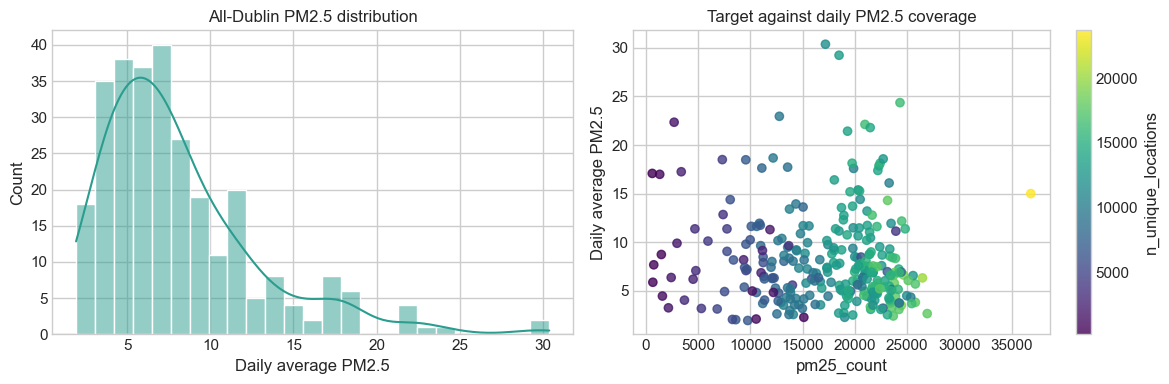

In [35]:
display(
    all_dublin['dublin_daily_avg_pm25']
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .round(3)
    .to_frame(name='dublin_daily_avg_pm25')
)

display(
    low_coverage_summary(
        all_dublin,
        target_col='dublin_daily_avg_pm25',
        coverage_cols=['pm25_count', 'n_unique_locations'],
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(all_dublin, x='dublin_daily_avg_pm25', bins=25, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('All-Dublin PM2.5 distribution')
axes[0].set_xlabel('Daily average PM2.5')

scatter = axes[1].scatter(
    all_dublin['pm25_count'],
    all_dublin['dublin_daily_avg_pm25'],
    c=all_dublin['n_unique_locations'],
    cmap='viridis',
    alpha=0.8,
)
axes[1].set_title('Target against daily PM2.5 coverage')
axes[1].set_xlabel('pm25_count')
axes[1].set_ylabel('Daily average PM2.5')
fig.colorbar(scatter, ax=axes[1], label='n_unique_locations')

plt.tight_layout()
plt.show()


The target remains suitable for regression: it is continuous, positive, and only moderately right-skewed. Coverage varies substantially across days, but low-coverage days do not show a clear mechanical break in the target, which supports keeping the all-Dublin series as the main modelling dataset.

**Takeaway.** The all-Dublin merged file is usable and reasonably stable after cleaning. Once weekends are treated as structurally out of scope, the data is fairly continuous, although the series still contains some unexpected missing weekdays and occasional low-coverage days.

### 5.2 North/South Dublin

As with the all-Dublin series, weekends are treated as structurally out of scope here, so continuity is assessed against an expected weekday-only sequence within each location subset.

In [36]:
location_continuity_rows = []
location_gap_rows = []
location_missing_rows = []

for label, subset in north_south.groupby('location_label'):
    summary, gap_summary, _, missing_blocks = weekday_continuity_diagnostics(subset['date'])
    summary.insert(0, 'location_label', label)
    gap_summary.insert(0, 'location_label', label)

    location_continuity_rows.append(summary)
    location_gap_rows.append(gap_summary)

    if len(missing_blocks) > 0:
        location_missing_rows.append(
            missing_blocks.assign(location_label=label)
            .sort_values('n_missing_weekdays', ascending=False)
            .head(4)
        )

location_continuity = pd.concat(location_continuity_rows, ignore_index=True)
location_gap_summary = (
    pd.concat(location_gap_rows, ignore_index=True)
    .pivot(index='location_label', columns='gap_type', values='n_links')
    .fillna(0)
    .astype(int)
    .reset_index()
)

display(location_continuity)
display(location_gap_summary)

if location_missing_rows:
    display(pd.concat(location_missing_rows, ignore_index=True))


,location_label,observational_unit,weekday_coverage,start_date,end_date,observed_rows,expected_weekday_rows,unexpected_missing_weekdays,share_expected_weekday_links,weekday_gaps_longer_than_expected,max_unexpected_weekday_gap
0,north,one observed Dublin weekday,"Friday, Monday, Thursday, Tuesday, Wednesday",2021-05-06,2022-08-05,249,327,78,0.810,47,9
1,south,one observed Dublin weekday,"Friday, Monday, Thursday, Tuesday, Wednesday",2021-05-06,2022-08-05,285,327,42,0.912,25,6


gap_type,location_label,expected Monday-after-Friday gap,expected next weekday,unexpected longer weekday gap
0,north,35,166,47
1,south,42,217,25


,block_start,block_end,n_missing_weekdays,location_label
0,2022-07-04,2022-07-08,5,north
1,2021-12-27,2021-12-31,5,north
2,2022-01-03,2022-01-06,4,north
3,2021-10-04,2021-10-06,3,north
4,2022-07-04,2022-07-08,5,south
5,2021-12-27,2021-12-31,5,south
6,2021-10-04,2021-10-06,3,south
7,2021-05-20,2021-05-21,2,south


Once weekends are excluded from the expected sequence, South looks close to the all-Dublin continuity profile, whereas North still shows substantially more unexpected missing weekdays and weaker weekday-to-weekday continuity.

Compare the target distribution and coverage profile by location to judge whether both subsets are credible enough for a lightweight robustness check.

,count,mean,std,min,5%,25%,50%,75%,95%,max
location_label,,,,,,,,,,
north,249.0,8.685,5.209,1.629,2.980,5.025,7.351,10.817,18.500,30.677
south,285.0,8.350,4.845,1.454,2.801,4.967,6.979,10.559,18.049,28.203


,location_label,low_coverage,coverage_rule,count,mean,median,std
0,north,False,pm25_count<=455.6,224,8.679,7.305,5.323
1,north,True,pm25_count<=455.6,25,8.731,8.427,4.136
2,south,False,pm25_count<=591.8,256,8.195,6.783,4.868
3,south,True,pm25_count<=591.8,29,9.712,9.788,4.491


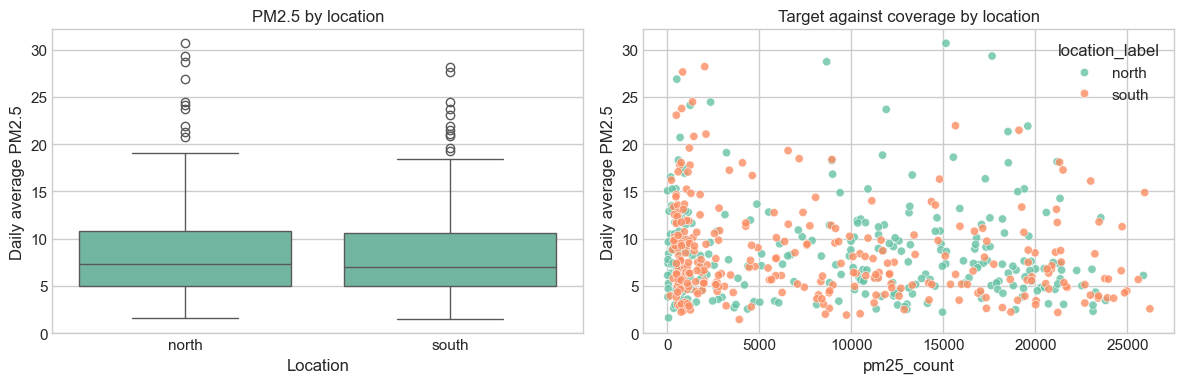

In [37]:
location_target_summary = (
    north_south.groupby('location_label')['dublin_daily_avg_pm25']
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .round(3)
)
display(location_target_summary)

location_coverage_summary = pd.concat(
    [
        low_coverage_summary(group, 'dublin_daily_avg_pm25', ['pm25_count']).assign(location_label=label)
        for label, group in north_south.groupby('location_label')
    ],
    ignore_index=True,
)
display(location_coverage_summary[['location_label', 'low_coverage', 'coverage_rule', 'count', 'mean', 'median', 'std']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=north_south, x='location_label', y='dublin_daily_avg_pm25', ax=axes[0])
axes[0].set_title('PM2.5 by location')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Daily average PM2.5')

sns.scatterplot(
    data=north_south,
    x='pm25_count',
    y='dublin_daily_avg_pm25',
    hue='location_label',
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Target against coverage by location')
axes[1].set_xlabel('pm25_count')
axes[1].set_ylabel('Daily average PM2.5')

plt.tight_layout()
plt.show()


North and South remain broadly comparable in PM2.5 levels, so the split does not create a fundamentally different target. The practical limitation is instead sample thickness: North has fewer observed days and more sparse-coverage days

**Takeaway.** South is fairly well aligned with the all-Dublin weekday regime, while North is still visibly thinner and should be interpreted more cautiously. Overall, should still be adequate for our purposes (robustness check).

## 6. Temporal features

### 6.1 Temporal dependence audit

This section audits temporal dependence in the observed all-Dublin weekday series only

In [38]:
from pathlib import Path

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ALL_DUBLIN_PATH = Path('../data/processed/merged_daily_dublin_avg_pm25_weather_traffic.csv')
target_col = 'dublin_daily_avg_pm25'

if 'all_dublin' not in globals():
    all_dublin = pd.read_csv(ALL_DUBLIN_PATH, parse_dates=['date'])

all_dublin = all_dublin.sort_values('date').reset_index(drop=True).copy()


View the target over time to see whether a short-memory structure looks plausible.

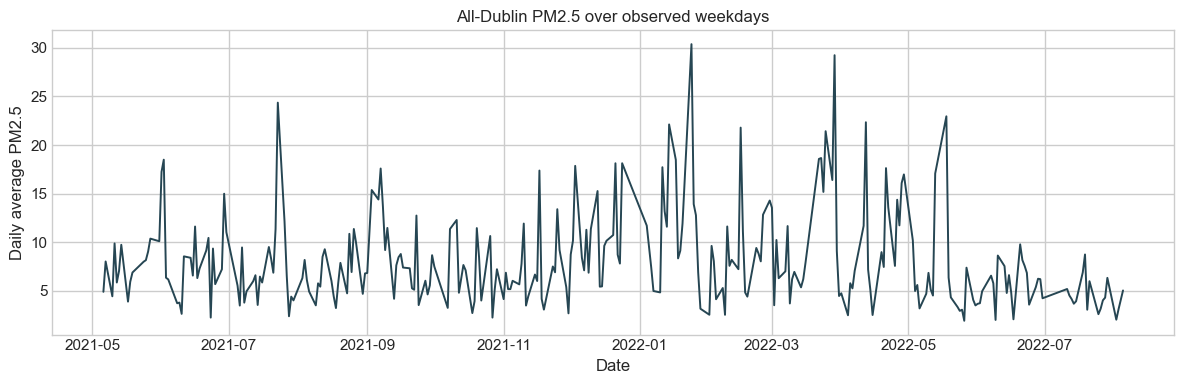

In [39]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(all_dublin['date'], all_dublin[target_col], color='#264653', linewidth=1.4)
ax.set_title('All-Dublin PM2.5 over observed weekdays')
ax.set_xlabel('Date')
ax.set_ylabel('Daily average PM2.5')
plt.tight_layout()
plt.show()


The series shows short-run persistence with occasional spikes, but not a slow-moving long-memory pattern. A short lag structure looks more defensible than a large set of distant lags.

Check whether weekday effects look strong enough to keep as a simple calendar feature.

,mean,median,count
day_name,,,
Monday,7.904,6.680,49
Tuesday,8.831,6.868,61
Wednesday,7.922,6.925,60
Thursday,7.382,6.859,60
Friday,8.410,7.174,56


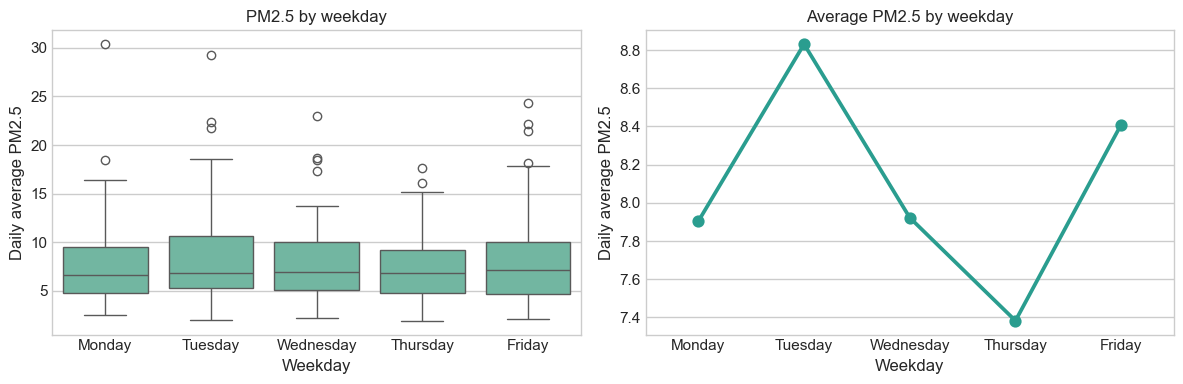

In [40]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=all_dublin, x='day_name', y=target_col, order=weekday_order, ax=axes[0])
axes[0].set_title('PM2.5 by weekday')
axes[0].set_xlabel('Weekday')
axes[0].set_ylabel('Daily average PM2.5')

weekday_summary = (
    all_dublin.groupby('day_name')[target_col]
    .agg(mean='mean', median='median', count='count')
    .reindex(weekday_order)
    .round(3)
)
display(weekday_summary)

sns.pointplot(
    data=all_dublin,
    x='day_name',
    y=target_col,
    order=weekday_order,
    errorbar=None,
    ax=axes[1],
    color='#2a9d8f',
)
axes[1].set_title('Average PM2.5 by weekday')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Daily average PM2.5')

plt.tight_layout()
plt.show()


ACF shows how strongly the PM2.5 series is correlated with its own previous observed values at different lags, while PACF isolates the additional contribution of each lag after accounting for the shorter lags before it.

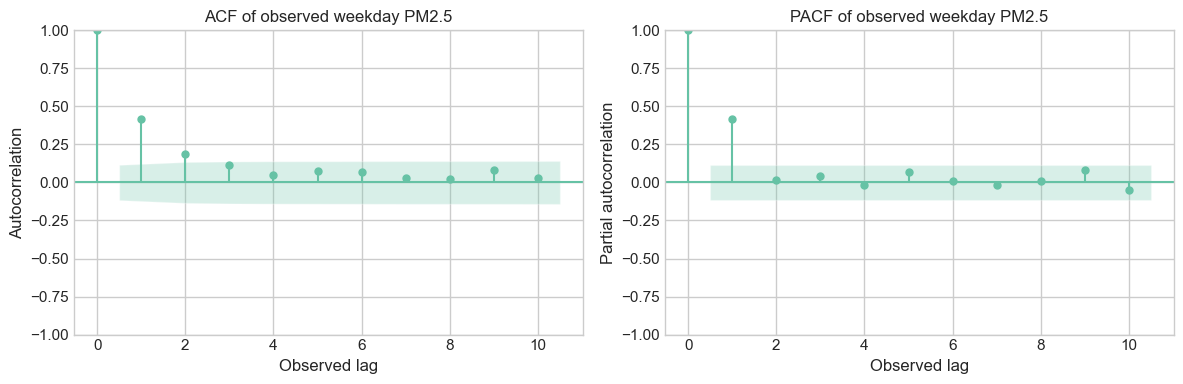

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(all_dublin[target_col], lags=10, ax=axes[0])
axes[0].set_title('ACF of observed weekday PM2.5')
axes[0].set_xlabel('Observed lag')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(all_dublin[target_col], lags=10, ax=axes[1], method='ywm')
axes[1].set_title('PACF of observed weekday PM2.5')
axes[1].set_xlabel('Observed lag')
axes[1].set_ylabel('Partial autocorrelation')

plt.tight_layout()
plt.show()


The dependence appears front-loaded: lag 1 is the clearest signal, with much weaker incremental structure after the first few observed lags. That supports a short lag design such as `lag_1` to `lag_3`

Visualise `lag_1` to `lag_3` relationships to gain more evidence to determine ideal lag

,lag,correlation_with_target
0,1,0.418
1,2,0.187
2,3,0.117


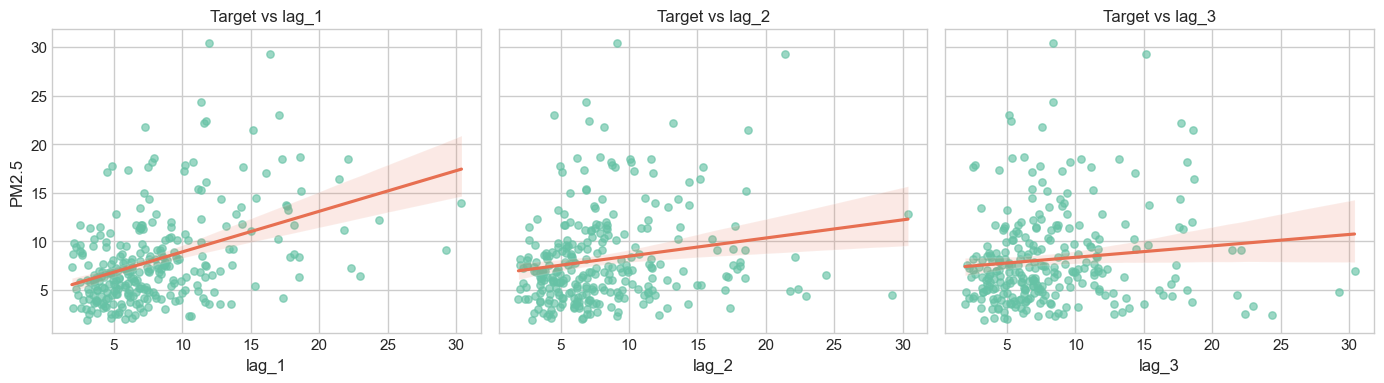

In [42]:
lag_check = all_dublin[['date', target_col]].copy()
for lag in [1, 2, 3]:
    lag_check[f'lag_{lag}'] = lag_check[target_col].shift(lag)

lag_corr = pd.DataFrame({
    'lag': [1, 2, 3],
    'correlation_with_target': [
        round(lag_check[target_col].corr(lag_check[f'lag_{lag}']), 3)
        for lag in [1, 2, 3]
    ],
})
display(lag_corr)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, lag in zip(axes, [1, 2, 3]):
    sns.regplot(
        data=lag_check,
        x=f'lag_{lag}',
        y=target_col,
        scatter_kws={'alpha': 0.65, 's': 28},
        line_kws={'color': '#e76f51'},
        ax=ax,
    )
    ax.set_title(f'Target vs lag_{lag}')
    ax.set_xlabel(f'lag_{lag}')
    ax.set_ylabel('PM2.5' if lag == 1 else '')

plt.tight_layout()
plt.show()


The direct lag checks tell the same story: `lag_1` carries the strongest information, `lag_2` still contributes some signal, and `lag_3` is weaker but still plausible as the upper end of a compact recent-history set.

#### Conclusion
The temporal diagnostics support keeping a short lag structure only. `lag_1` is the strongest and most defensible persistence feature, while `lag_2` and `lag_3` are still plausible as a compact recent-history extension; more distant lags do not look necessary at this stage. Weekday differences are visible but modest, so they are best handled with the existing `day_of_week` indicator rather than with more elaborate calendar features.

### 6.2 Temporal feature construction

Create the temporal features in a notebook dataframe so the original merged CSV remains unchanged

In [43]:
all_dublin_temporal = all_dublin.copy()

for lag in [1, 2, 3]:
    all_dublin_temporal[f'lag_{lag}'] = all_dublin_temporal[target_col].shift(lag)

temporal_feature_cols = ['day_of_week', 'lag_1', 'lag_2', 'lag_3']
model_df = all_dublin_temporal.copy()

display(model_df[['date', target_col] + temporal_feature_cols].head(8))


,date,dublin_daily_avg_pm25,day_of_week,lag_1,lag_2,lag_3
0,2021-05-06,4.903776,3,NaN,NaN,NaN
1,2021-05-07,8.028253,4,4.903776,NaN,NaN
2,2021-05-10,4.443267,0,8.028253,4.903776,NaN
3,2021-05-11,9.881657,1,4.443267,8.028253,4.903776
4,2021-05-12,5.863840,2,9.881657,4.443267,8.028253
5,2021-05-13,7.057951,3,5.863840,9.881657,4.443267
6,2021-05-14,9.739638,4,7.057951,5.863840,9.881657
7,2021-05-17,3.897264,0,9.739638,7.057951,5.863840


N.B. the first three rows are expected to be incomplete because the lag features need prior observed weekdays.

In [44]:
all_dublin_temporal.head()

,date,day_name,day_of_week,is_weekend,dublin_daily_avg_pm25,pm25_count,n_unique_locations,pm25_min,pm25_max,maxtp,...,pe,evap,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_n_sites,dublin_daily_n_regions,lag_1,lag_2,lag_3
0,2021-05-06,Thursday,3,0,4.903776,7518,5684,0.702,107.655,12.0,...,2.8,4.4,17149.593217,16134.928571,14458493,865,7,NaN,NaN,NaN
1,2021-05-07,Friday,4,0,8.028253,13206,7902,1.023,764.816,11.1,...,2.7,4.1,17920.225608,17037.785714,15133373,866,7,4.903776,NaN,NaN
2,2021-05-10,Monday,0,0,4.443267,1566,1112,0.195,101.522,15.3,...,2.4,3.5,16803.592495,15754.428571,14089843,864,7,8.028253,4.903776,NaN
3,2021-05-11,Tuesday,1,0,9.881657,2964,1764,3.730,69.970,14.1,...,2.9,4.7,17419.522593,16005.642857,14678272,866,7,4.443267,8.028253,4.903776
4,2021-05-12,Wednesday,2,0,5.863840,650,522,0.596,31.540,12.3,...,1.9,2.8,17497.224895,16398.214286,14770830,865,7,9.881657,4.443267,8.028253


## 7. Exogenous predictor selection

### 7.1 Correlation martrix TRAFFIC

This section explores the relationship between the traffic features and the target to inform feature selection. 

In [45]:
DATA_DIR = Path('../data/processed')
ALL_DUBLIN_PATH = DATA_DIR / 'merged_daily_dublin_avg_pm25_weather_traffic.csv'

df = pd.read_csv(ALL_DUBLIN_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)

In [46]:
# Correlation Matrix of the Traffic Features
cols = ['dublin_daily_mean_site_traffic',
       'dublin_daily_median_site_traffic', 'dublin_daily_total_traffic', 'dublin_daily_avg_pm25']

# Compute correlation matrix
corr = df[cols].corr()

corr

,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_avg_pm25
dublin_daily_mean_site_traffic,1.000000,0.968963,0.786742,-0.046062
dublin_daily_median_site_traffic,0.968963,1.000000,0.723199,-0.022471
dublin_daily_total_traffic,0.786742,0.723199,1.000000,0.001022
dublin_daily_avg_pm25,-0.046062,-0.022471,0.001022,1.000000


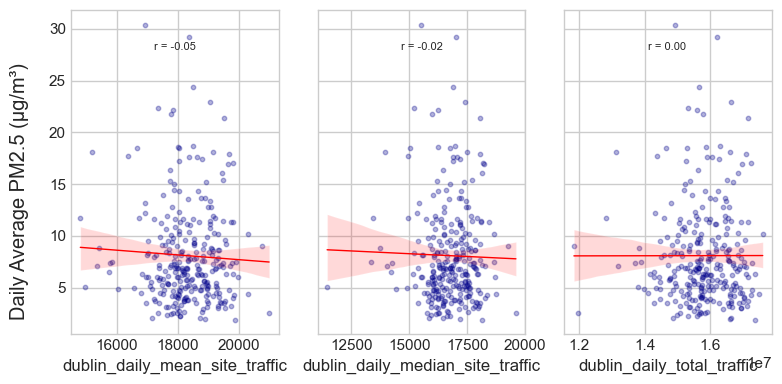

In [47]:
# Scatter plots grid of the traffic levels features and dublin_daily_avg_pm25

fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharey = True)
cols = ['dublin_daily_mean_site_traffic',
       'dublin_daily_median_site_traffic', 'dublin_daily_total_traffic']

for ax, col in zip(axes.flat, cols):
    sns.regplot(
        data=df,
        x=col,
        y="dublin_daily_avg_pm25",
        ax=ax,
        scatter_kws={"s": 10, "color": "darkblue", "alpha": 0.3},    #t
        line_kws={"color": "red", "linewidth": 1}
    )
    ax.set_title("")
    ax.set_ylabel("")

    r = df[[col, "dublin_daily_avg_pm25"]].corr().iloc[0, 1]
    ax.text(
        0.4, 0.9,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top'
      )

fig.supylabel("Daily Average PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

We can observe similar distribution of points in the scatter plots for the mean, median and total traffic measures. Daily median site traffic has slightly less spread of points than the mean. 

### 7.2 Correlation martrix WEATHER

This section explores the relationship between the weather features, and with the target to inform feature selection. 

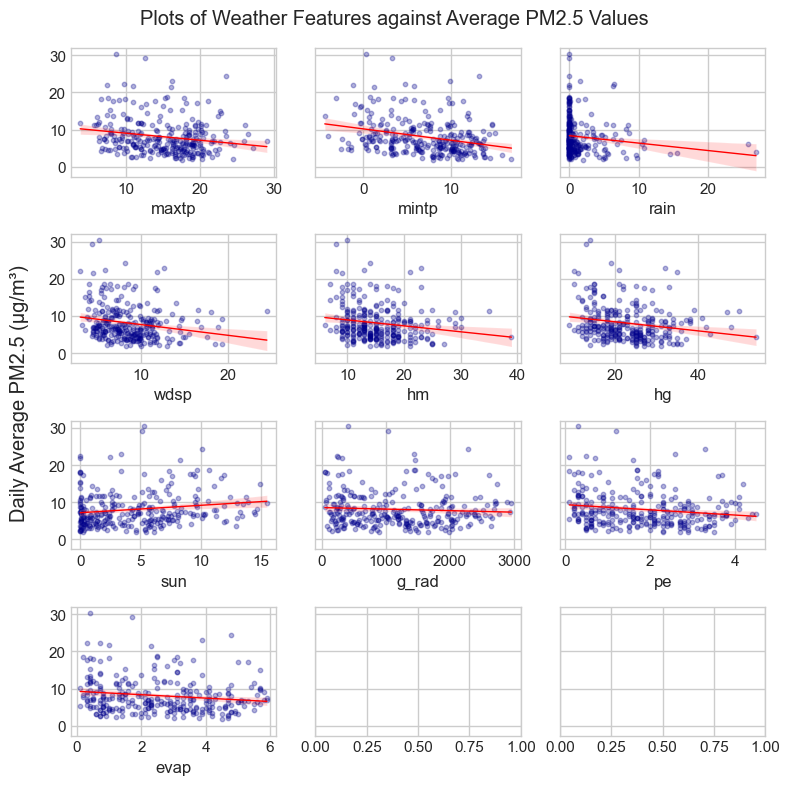

(None,)

In [48]:
# Plots of weather features against dublin_daily_avg_pm25
fig, axes = plt.subplots(4, 3, figsize=(8, 8), sharey = True)

cols = ['maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap'] #weather cols

for ax, col in zip(axes.flat, cols):
    sns.regplot(
        data=df,
        x=col,
        y="dublin_daily_avg_pm25",
        ax=ax,
        scatter_kws={"s": 10, "color": "darkblue", "alpha": 0.3},    #t
        line_kws={"color": "red", "linewidth": 1}
    )
    ax.set_title("")
    ax.set_ylabel("")

fig.supylabel("Daily Average PM2.5 (µg/m³)") #super i.e for all
fig.suptitle("Plots of Weather Features against Average PM2.5 Values")
fig.subplots_adjust(hspace=0.4) 
plt.tight_layout()

plt.show(), 


We observe differences each feature has with the target, in particular how condensed rain is along the x-axis. Additionally we see that many of the weather features has a similar slight negative trend with the target, e.g. max temp and min temp where including both may be redundant. Sun is the only feature which has a positive association with the daily PM2.5 measure.

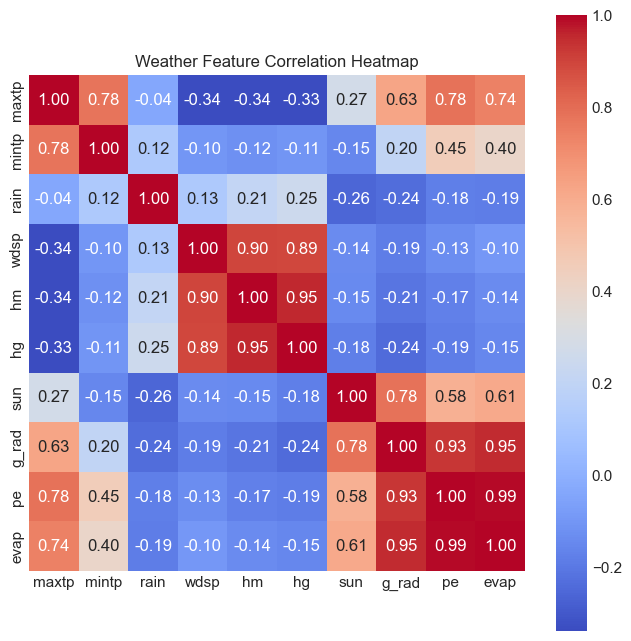

In [49]:
# Correlation Heatmap of the Weather Features
cols = ['maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap']

# Compute correlation matrix
corr = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Weather Feature Correlation Heatmap")
plt.show()

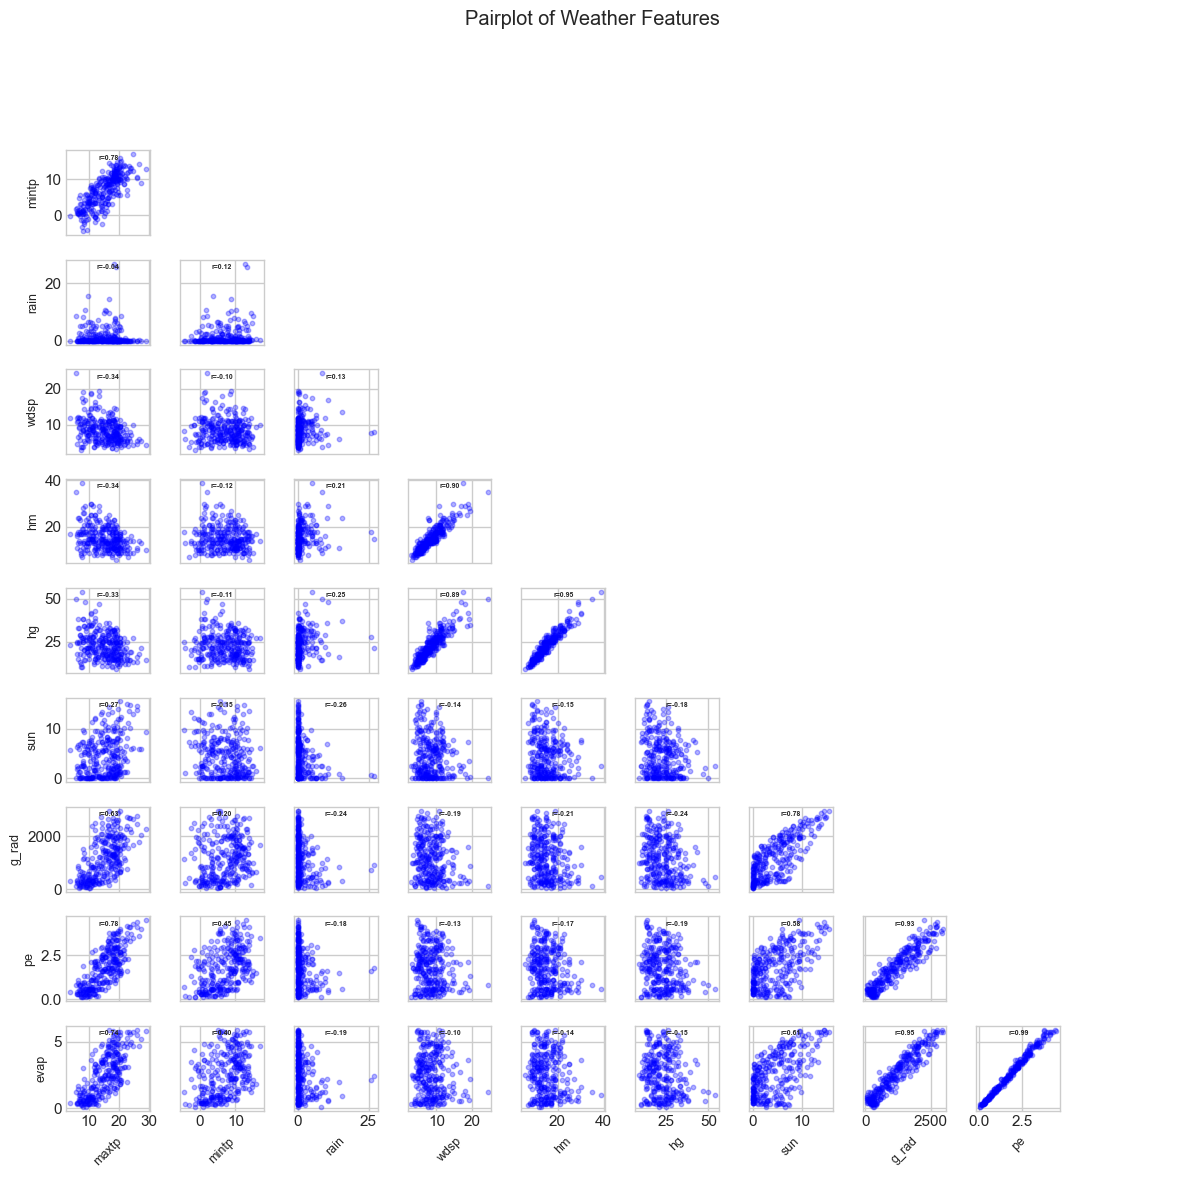

In [50]:
# Scatter plot of matrix of weather features
cols = ['maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap'] #all weather measurements

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
for i in range(10):
    for j in range(10):
        ax = axes[i, j]

        if i > j:  # lower triangle
            x = df[cols[j]]
            y = df[cols[i]]

            ax.scatter(x, y, s=10, alpha=0.3, color='blue') #points

            r = x.corr(y) #correltaion
            ax.text(0.5, 0.95, f"r={r:.2f}", transform=ax.transAxes,
                    ha='center', va='top', fontsize=5, fontweight='bold')

        else:
            ax.axis('off')  # hide upper triangle & diagonal

        if j == 0 and i > 0:
            ax.set_ylabel(cols[i], fontsize=9)
        else:
            ax.set_yticklabels([])

        if i == 9 and j < 9:
            ax.set_xlabel(cols[j], fontsize=9, rotation=45)
        else:
            ax.set_xticklabels([])
            
fig.suptitle("Pairplot of Weather Features")
plt.tight_layout()
plt.show()

The above correlation heatmap and pairs plot highlight how many of the weather features are highly correlated. `pe` and `evap` for instance are exceptionally highly correlated and would likely be redundant and add little value to the model as it does not help the model gain new information.

### 7.3 Forecasting feature set decision + implementation

From the traffic and weather diagnostics above, we retain the exogenous variables that add distinct information and remove those that are either redundant, uninformative, or not appropriate as forecasting predictors.

Which forecasting variables we drop:
- Drop `dublin_daily_median_site_traffic` and keep `dublin_daily_mean_site_traffic`, because the mean shows slightly more variation that could help explain `dublin_daily_avg_pm25`.
- Drop `rain`, because it appears effectively unrelated to `dublin_daily_avg_pm25`.
- Drop `pe`, because it is conceptually similar and materially near-equal to `evap` (correlation = 0.99).
- Drop `hm`, because it is conceptually similar to `evap` and also materially near-equal to it (correlation = 0.95).

Which non-forecast predictors we drop:
- Drop `pm25_count`, `n_unique_locations`, `pm25_min`, and `pm25_max`, because these describe coverage or within-day dispersion of the realised target rather than usable forecasting inputs.
- Drop `dublin_daily_n_sites`, `dublin_daily_n_regions`, and `dublin_daily_total_traffic`, because these are data-collection coverage measures rather than substantive next-day forecasting predictors.
- Drop `day_name`, because it duplicates `day_of_week`.
- Drop `is_weekend`, because the modelling dataset is weekday-only, so this variable has no variation.

We therefore implement both the forecasting-variable drop and the non-forecast-predictor drop directly on `model_df` before moving into modelling.

In [51]:
drop_forecasting_variable_cols = [
    'dublin_daily_median_site_traffic',
    'rain',
    'pe',
    'hm',
]

drop_non_forecast_predictor_cols = [
    'pm25_count',
    'n_unique_locations',
    'pm25_min',
    'pm25_max',
    'dublin_daily_n_sites',
    'dublin_daily_n_regions',
    'dublin_daily_total_traffic',
    'day_name',
    'is_weekend',
]

cols_to_drop = [
    col for col in (drop_forecasting_variable_cols + drop_non_forecast_predictor_cols)
    if col in model_df.columns
]
model_df = model_df.drop(columns=cols_to_drop)

print('Dropped from model_df:', cols_to_drop)
print('Remaining columns in model_df:')
print(model_df.columns.tolist())
display(model_df.head())


Dropped from model_df: ['dublin_daily_median_site_traffic', 'rain', 'pe', 'hm', 'pm25_count', 'n_unique_locations', 'pm25_min', 'pm25_max', 'dublin_daily_n_sites', 'dublin_daily_n_regions', 'dublin_daily_total_traffic', 'day_name', 'is_weekend']
Remaining columns in model_df:
['date', 'day_of_week', 'dublin_daily_avg_pm25', 'maxtp', 'mintp', 'wdsp', 'hg', 'sun', 'g_rad', 'evap', 'dublin_daily_mean_site_traffic', 'lag_1', 'lag_2', 'lag_3']


,date,day_of_week,dublin_daily_avg_pm25,maxtp,mintp,wdsp,hg,sun,g_rad,evap,dublin_daily_mean_site_traffic,lag_1,lag_2,lag_3
0,2021-05-06,3,4.903776,12.0,-1.7,9.9,26,12.1,2489,4.4,17149.593217,NaN,NaN,NaN
1,2021-05-07,4,8.028253,11.1,0.6,8.5,21,11.3,2394,4.1,17920.225608,4.903776,NaN,NaN
2,2021-05-10,0,4.443267,15.3,8.0,10.8,27,2.6,1312,3.5,16803.592495,8.028253,4.903776,NaN
3,2021-05-11,1,9.881657,14.1,2.6,9.9,23,13.0,2716,4.7,17419.522593,4.443267,8.028253,4.903776
4,2021-05-12,2,5.863840,12.3,0.3,4.8,16,3.2,1620,2.8,17497.224895,9.881657,4.443267,8.028253


## 8. Baseline model(s)

Create one shared chronological train-test split on the observed rows in `model_df`. All subsequent models in this section can draw from this split, and then apply any model-specific preprocessing afterwards.

In [171]:
# shared chronological train-test split on observed model_df rows
shared_model_df = model_df.copy()
shared_model_df['date'] = shared_model_df['date'].astype('datetime64[ns]')
shared_model_df = shared_model_df.sort_values('date').reset_index(drop=True)

eighty_pct = int(len(shared_model_df) * .8)

train_df = shared_model_df.iloc[:eighty_pct].copy()
test_df = shared_model_df.iloc[eighty_pct:].copy()

print(f" Train values: {train_df['date'].min()} --- {train_df['date'].max()} n={len(train_df)}")
print(f" Test values: {test_df['date'].min()} --- {test_df['date'].max()} n={len(test_df)}")


 Train values: 2021-05-06 00:00:00 --- 2022-04-28 00:00:00 n=228
 Test values: 2022-04-29 00:00:00 --- 2022-08-05 00:00:00 n=58


### 8.1 `same_weekday_average_forecaster`

For the baseline model I chose to forecast based on an average model. This took the average of the last 4 values of that weekday and used it as the prediction for all of those future weekdays. I used business days as the frequency to account for the fact that there is only weekday data and no weekends.

In [53]:
# convert the shared split to business-day frequency for this baseline model
data_train = train_df.set_index('date').asfreq('B').ffill()
data_test  = test_df.set_index('date').asfreq('B').ffill()

y_train = data_train['dublin_daily_avg_pm25']
y_test  = data_test['dublin_daily_avg_pm25']


In [54]:
# check the effective train-test range for this business-day-frequency baseline
print(f" Train values: {data_train.index.min()} --- {data_train.index.max()} n={len(data_train)}")
print(f" Test values: {data_test.index.min()} --- {data_test.index.max()} n={len(data_test)}")

 Train values: 2021-05-06 00:00:00 --- 2022-04-28 00:00:00 n=256
 Test values: 2022-04-29 00:00:00 --- 2022-08-05 00:00:00 n=71


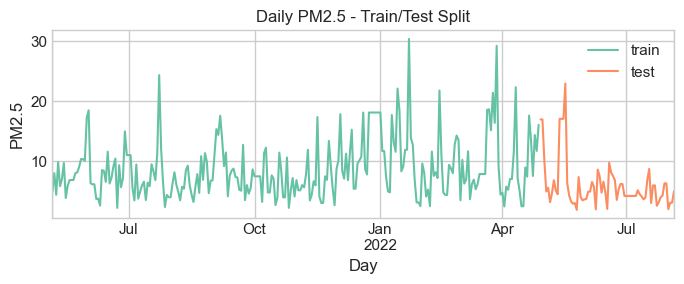

In [55]:
# Plot train-test split
fig, ax = plt.subplots(figsize=(7, 3))
y_train.plot(ax=ax, label='train')
y_test.plot(ax=ax, label='test')
ax.set_title('Daily PM2.5 - Train/Test Split')
ax.legend()
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

In [56]:
# fit the 4-week same-weekday average forecaster
same_weekday_average_forecaster = ForecasterEquivalentDate(
    offset = pd.DateOffset(weeks=1), 
    n_offsets = 4, # average of last 4 equivalent weekdays
    agg_func = np.mean) # use the mean

same_weekday_average_forecaster.fit(y=y_train)
same_weekday_average_forecaster

======================== 
ForecasterEquivalentDate 
======================== 
Offset: <DateOffset: weeks=1> 
Number of offsets: 4 
Aggregation function: mean 
Window size: 20 
Series name: dublin_daily_avg_pm25 
Training range: [Timestamp('2021-05-06 00:00:00'), Timestamp('2022-04-28 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <BusinessDay> 
Creation date: 2026-04-01 21:28:19 
Last fit date: 2026-04-01 21:28:19 
Skforecast version: 0.21.0 
Python version: 3.13.5 
Forecaster id: None

In [57]:
# make predictions
predictions = same_weekday_average_forecaster.predict(steps=len(y_test)) # predicts for the number of values in test set
predictions.head(20)

2022-04-29     6.988515
2022-05-02     6.067794
2022-05-03    12.875271
2022-05-04     7.911883
2022-05-05    11.474027
2022-05-06     6.988515
2022-05-09     6.067794
2022-05-10    12.875271
2022-05-11     7.911883
2022-05-12    11.474027
2022-05-13     6.988515
2022-05-16     6.067794
2022-05-17    12.875271
2022-05-18     7.911883
2022-05-19    11.474027
2022-05-20     6.988515
2022-05-23     6.067794
2022-05-24    12.875271
2022-05-25     7.911883
2022-05-26    11.474027
Freq: B, Name: pred, dtype: float64

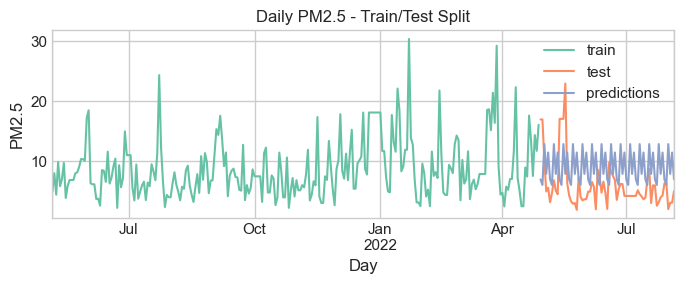

In [58]:
# plot predictions
fig, ax = plt.subplots(figsize=(7, 3))
y_train.plot(ax=ax, label='train')
y_test.plot(ax=ax, label='test')
predictions.plot(ax=ax, label = 'predictions')
ax.set_title('Daily PM2.5 - Train/Test Split')
ax.legend()
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

In [59]:
# assess using MSE and RMSE
mse = mean_squared_error(
    y_true = y_test,
    y_pred = predictions
)
print(f" Mean Squared Error: {mse}")

rmse = sqrt(mse)
print(f" Root Mean Sqaured Error: {rmse}")

 Mean Squared Error: 35.07413876222187
 Root Mean Sqaured Error: 5.922342337472722


#### 8.1.1 For curiosities sake

### 8.2 `y_hat_t = y_(t-1)`

This baseline predicts each observed test-day PM2.5 value using the previous observed PM2.5 value. The first test prediction therefore uses the last observed training value.

In [60]:
# prepare the observed-row target series for the t-1 baseline
observed_train_target = train_df.set_index('date')['dublin_daily_avg_pm25']
observed_test_target = test_df.set_index('date')['dublin_daily_avg_pm25']
observed_full_target = shared_model_df.set_index('date')['dublin_daily_avg_pm25']

t_minus_1_predictions = observed_full_target.shift(1).loc[observed_test_target.index]

display(
    pd.DataFrame({
        'y_true': observed_test_target,
        'y_hat_t_minus_1': t_minus_1_predictions,
    }).head(10)
)


,y_true,y_hat_t_minus_1
date,,
2022-04-29,16.982060,16.090699
2022-05-03,10.190971,16.982060
2022-05-04,4.984631,10.190971
2022-05-05,5.605879,4.984631
2022-05-06,3.196438,5.605879
2022-05-09,4.700539,3.196438
2022-05-10,6.852294,4.700539
2022-05-11,5.132344,6.852294
2022-05-12,4.519912,5.132344


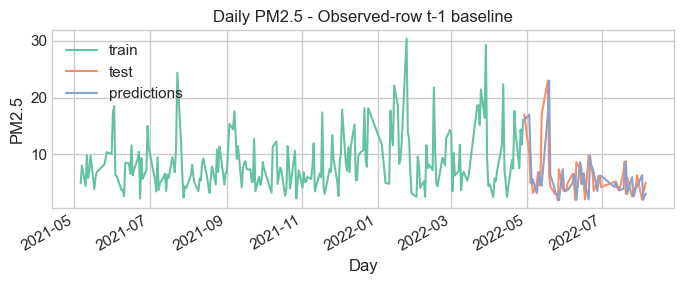

In [61]:
# plot the t-1 predictions against the observed test values
fig, ax = plt.subplots(figsize=(7, 3))
observed_train_target.plot(ax=ax, label='train')
observed_test_target.plot(ax=ax, label='test')
t_minus_1_predictions.plot(ax=ax, label='predictions')
ax.set_title('Daily PM2.5 - Observed-row t-1 baseline')
ax.legend()
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()


In [62]:
# assess the t-1 baseline using MSE and RMSE
t_minus_1_mse = mean_squared_error(
    y_true=observed_test_target,
    y_pred=t_minus_1_predictions,
)
print(f" Mean Squared Error: {t_minus_1_mse}")

t_minus_1_rmse = sqrt(t_minus_1_mse)
print(f" Root Mean Squared Error: {t_minus_1_rmse}")


 Mean Squared Error: 14.966507115117285
 Root Mean Squared Error: 3.868657016991463


In [63]:
## Function to create a sliding window
def get_window(df, window_size, window_columns, other_columns):

    X = []
    for i in range(len(df) - window_size):
        window = []

        # Collect data for each column in the specified window
        for col in window_columns:
            window.extend(df[col].iloc[i:i+window_size].values)

        # Add the other columns only once (for the current day) - non time series features for day you are trying to predict
        # things you already know about the day you are predicting
        for col in other_columns:
            window.append(df[col].iloc[i])
        X.append(window)

    return np.array(X)

In [64]:
# Create windows for each column
window_size = 2 # Use the previous 3 days of data
window_params = ['dublin_daily_avg_pm25','sun', 'wdsp'] # use the pm25, sun, wind speed
other_params = ['day_of_week'] # we know what day of the week it will be
output_param = ['dublin_daily_avg_pm25'] # predict the temperature

X = get_window(all_dublin, window_size, window_params, other_params)
y = all_dublin[output_param][window_size:].values

# Check they are the same length
print(X.shape, len(y))

## How many parameters do we have as input?
print(len(X[0]))

(284, 7) 284
7


In [65]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) ## do not set shuffle to True

In [66]:
## Use some regression models (eg LinearRegression(), RandomForestRegressor())

## fit the model using X_train, y_train

# linear regression
model = LinearRegression()

# fit model
model.fit(X_train, y_train)

# Make predictions for X_test
y_pred = model.predict(X_test)

# Evaluate performance of the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f" MAE: {mae}, MSE: {mse}, RMSE: {rmse}")

 MAE: 3.3214287136554095, MSE: 16.119388164600096, RMSE: 4.014895785023579


[[ 0.03034823  0.32507992  0.06621585  0.14685614  0.16249767 -0.19126134
   0.19926747]]


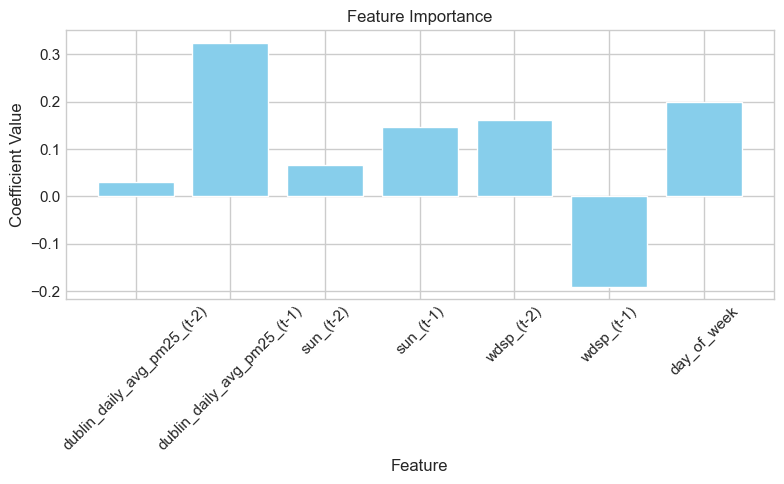

In [67]:
## get the model coefficients
print(model.coef_)
model_coeffs = model.coef_
model_coeffs = model_coeffs.flatten() # flatten to 1D
feature_names = [f'{param}_(t-{window_size - i})' for param in window_params for i in range(window_size)]+other_params


# Create a bar chart for the feature importance
plt.figure(figsize=(8, 5))
plt.bar(feature_names, model_coeffs, color='skyblue')

# Add titles and labels
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Show the plot
plt.tight_layout()
plt.show()

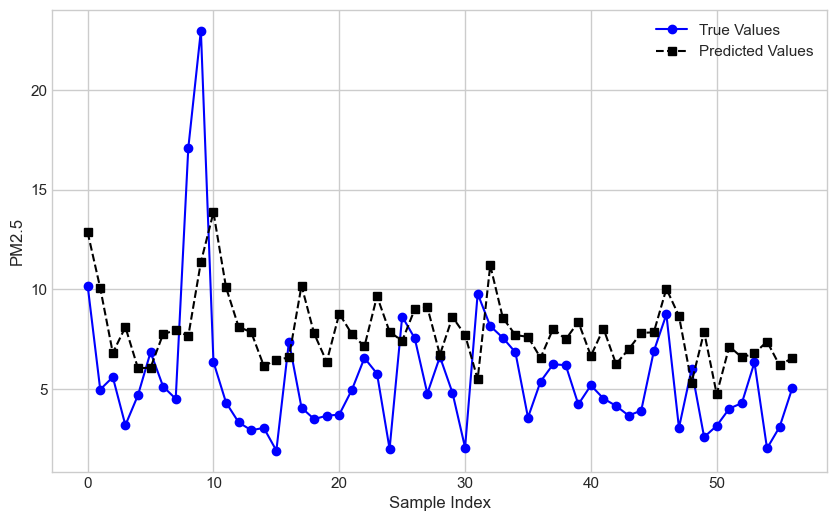

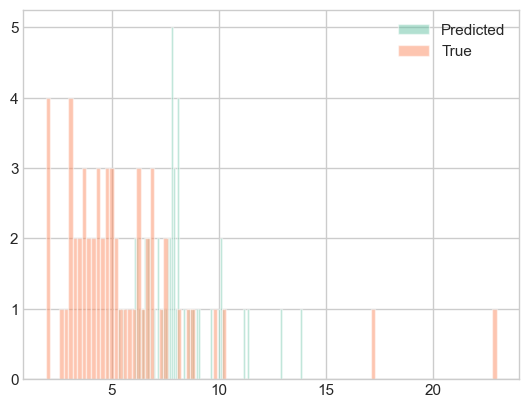

In [68]:
# Create a plot to compare the true values and the predicted values
plt.figure(figsize=(10, 6))

# Plot true values (actual values from y_test)
plt.plot(y_test[:100], label='True Values', color='blue', linestyle='-', marker='o')

# Plot predicted values (from the model)
plt.plot(y_pred[:100], label='Predicted Values', color='black', linestyle='--', marker='s')

# Add labels and title
plt.xlabel('Sample Index')
plt.ylabel('PM2.5')

#plt.ylabel('Daily Rainfall (mm)')
plt.legend()

# Show the plot
plt.show()

plt.hist(y_pred,100, alpha = 0.5, label = 'Predicted')
plt.hist(y_test, 100, alpha = 0.5, label = 'True')
plt.legend()
plt.show()

## 9. Forecasting models
work with `shared_model_df`

### 9.1 Direct one-step-ahead Ridge ARX

This model predicts next-day Dublin-wide PM2.5 directly from information available at forecast time. It combines recent PM2.5 lags (`lag_1` to `lag_3`) with lagged weather and traffic predictors from the previous observed day, and it keeps `day_of_week` as a known calendar input for the forecast day.

This is a suitable full model for the project because 
- the task is one-step-ahead prediction, 
- the sample is relatively small, 
- several retained weather variables remain correlated

Ridge regularisation shrinks unstable coefficients without sacrificing interpretability, so it is a sensible ARX specification for a compact city-day dataset like this one

#### Build the forecast-time aligned modelling dataset

In [69]:
# Build a direct one-step-ahead dataset on the observed city-day rows
# The target stays on date t, while weather and traffic inputs are lagged by one observed day so the model only uses information available at forecast time
ridge_arx_df = shared_model_df.copy()

# These are the exogenous series observed on day t-1 that we let the model use for day t.
ridge_arx_lagged_exog_source_cols = [
    'maxtp',
    'mintp',
    'wdsp',
    'hg',
    'sun',
    'g_rad',
    'evap',
    'dublin_daily_mean_site_traffic',
]

for col in ridge_arx_lagged_exog_source_cols:
    ridge_arx_df[f'{col}_lag_1'] = ridge_arx_df[col].shift(1)

ridge_arx_numeric_feature_cols = [
    'lag_1',
    'lag_2',
    'lag_3',
] + [f'{col}_lag_1' for col in ridge_arx_lagged_exog_source_cols]

ridge_arx_calendar_feature_cols = ['day_of_week']
ridge_arx_target_col = 'dublin_daily_avg_pm25'

# Keep only the aligned target date, the target itself, and the predictors we want to model with.
# The first rows drop out here as they should because the lag structure is not fully available yet.
ridge_arx_df = ridge_arx_df[
    ['date', ridge_arx_target_col] + ridge_arx_calendar_feature_cols + ridge_arx_numeric_feature_cols
].dropna().reset_index(drop=True)

# use the shared chronological split from section 8 by assigning each supervised row to the train or test window according to its target date.
ridge_arx_train_end_date = train_df['date'].max()
ridge_arx_test_start_date = test_df['date'].min()

ridge_arx_train = ridge_arx_df[ridge_arx_df['date'] <= ridge_arx_train_end_date].copy()
ridge_arx_test = ridge_arx_df[ridge_arx_df['date'] >= ridge_arx_test_start_date].copy()

print(f" Train values: {ridge_arx_train['date'].min()} --- {ridge_arx_train['date'].max()} n={len(ridge_arx_train)}")
print(f" Test values: {ridge_arx_test['date'].min()} --- {ridge_arx_test['date'].max()} n={len(ridge_arx_test)}")

display(ridge_arx_train.head())


 Train values: 2021-05-11 00:00:00 --- 2022-04-28 00:00:00 n=225
 Test values: 2022-04-29 00:00:00 --- 2022-08-05 00:00:00 n=58


,date,dublin_daily_avg_pm25,day_of_week,lag_1,lag_2,lag_3,maxtp_lag_1,mintp_lag_1,wdsp_lag_1,hg_lag_1,sun_lag_1,g_rad_lag_1,evap_lag_1,dublin_daily_mean_site_traffic_lag_1
0,2021-05-11,9.881657,1,4.443267,8.028253,4.903776,15.3,8.0,10.8,27.0,2.6,1312.0,3.5,16803.592495
1,2021-05-12,5.863840,2,9.881657,4.443267,8.028253,14.1,2.6,9.9,23.0,13.0,2716.0,4.7,17419.522593
2,2021-05-13,7.057951,3,5.863840,9.881657,4.443267,12.3,0.3,4.8,16.0,3.2,1620.0,2.8,17497.224895
3,2021-05-14,9.739638,4,7.057951,5.863840,9.881657,14.2,1.9,4.6,11.0,9.1,2068.0,3.5,17950.464027
4,2021-05-17,3.897264,0,9.739638,7.057951,5.863840,14.2,2.6,6.5,18.0,5.3,1872.0,3.4,18534.467381


#### Preprocess features for Ridge ARX

In [70]:
# Scale continuous predictors so Ridge penalises them on a comparable scale.
# Treat day_of_week as categorical by expanding it into weekday indicator columns.
ridge_arx_feature_cols = ridge_arx_calendar_feature_cols + ridge_arx_numeric_feature_cols

ridge_arx_preprocessor = ColumnTransformer(
    transformers=[
        ('scale_numeric', StandardScaler(), ridge_arx_numeric_feature_cols),
        ('encode_day', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ridge_arx_calendar_feature_cols),
    ]
)

# Bundle preprocessing and estimation together so the same steps are applied
# during tuning, final fitting, and prediction.
def make_ridge_arx_pipeline(alpha):
    return Pipeline([
        ('preprocessor', ridge_arx_preprocessor),
        ('ridge', Ridge(alpha=alpha)),
    ])

# Keep the full training data ready for the final model fit later on.
ridge_arx_X_train = ridge_arx_train[ridge_arx_feature_cols]
ridge_arx_y_train = ridge_arx_train[ridge_arx_target_col]


#### Tune the Ridge penalty

In [71]:
# Split the training period once more into an earlier inner-training window and a later validation window (so we don't touch the actual test set)
ridge_arx_validation_size = int(np.ceil(len(ridge_arx_train) * 0.2))

ridge_arx_inner_train = ridge_arx_train.iloc[:-ridge_arx_validation_size].copy()
ridge_arx_validation = ridge_arx_train.iloc[-ridge_arx_validation_size:].copy()

ridge_arx_X_inner_train = ridge_arx_inner_train[ridge_arx_feature_cols]
ridge_arx_y_inner_train = ridge_arx_inner_train[ridge_arx_target_col]
ridge_arx_X_validation = ridge_arx_validation[ridge_arx_feature_cols]
ridge_arx_y_validation = ridge_arx_validation[ridge_arx_target_col]

print(
    f" Inner train values: {ridge_arx_inner_train['date'].min()} --- "
    f"{ridge_arx_inner_train['date'].max()} n={len(ridge_arx_inner_train)}"
)
print(
    f" Validation values: {ridge_arx_validation['date'].min()} --- "
    f"{ridge_arx_validation['date'].max()} n={len(ridge_arx_validation)}"
)

# Try a small grid of candidate alpha values, score each one on the validation window, keep the alpha with the lowest validation RMSE.
ridge_arx_alpha_grid = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_arx_validation_rows = []

for alpha in ridge_arx_alpha_grid:
    ridge_arx_validation_model = make_ridge_arx_pipeline(alpha=alpha)
    ridge_arx_validation_model.fit(ridge_arx_X_inner_train, ridge_arx_y_inner_train)
    ridge_arx_validation_preds = ridge_arx_validation_model.predict(ridge_arx_X_validation)

    ridge_arx_validation_rmse = sqrt(
        mean_squared_error(ridge_arx_y_validation, ridge_arx_validation_preds)
    )

    ridge_arx_validation_rows.append({
        'alpha': alpha,
        'validation_rmse': ridge_arx_validation_rmse,
    })

ridge_arx_validation_results = (
    pd.DataFrame(ridge_arx_validation_rows)
    .sort_values('validation_rmse')
    .reset_index(drop=True)
)


 Inner train values: 2021-05-11 00:00:00 --- 2022-02-16 00:00:00 n=180
 Validation values: 2022-02-17 00:00:00 --- 2022-04-28 00:00:00 n=45


#### Plot alpha against validation RMSE

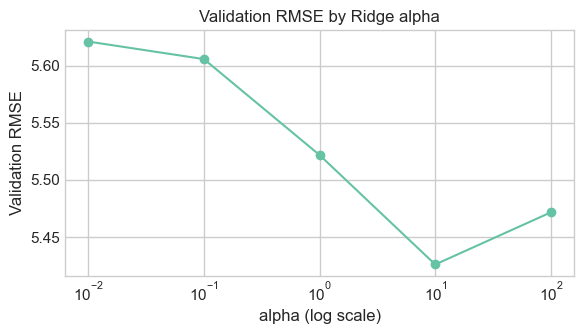

In [72]:
ridge_arx_validation_plot = ridge_arx_validation_results.sort_values('alpha')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(
    ridge_arx_validation_plot['alpha'],
    ridge_arx_validation_plot['validation_rmse'],
    marker='o'
)
ax.set_xscale('log')
ax.set_title('Validation RMSE by Ridge alpha')
ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('Validation RMSE')
plt.tight_layout()
plt.show()


**Suggests `10` is the best value of `alpha`**

#### Fit the final Ridge ARX model and evaluate test performance

In [73]:
# Fit the final Ridge ARX model on the full training window and evaluate it on
# the held-out test period.
ridge_arx_X_test = ridge_arx_test[ridge_arx_feature_cols]
ridge_arx_y_test = ridge_arx_test[ridge_arx_target_col]

# Refit the chosen model on the full training window before forecasting the held-out test period.
ridge_arx_model = make_ridge_arx_pipeline(alpha=10)
ridge_arx_model.fit(ridge_arx_X_train, ridge_arx_y_train)

# Keep the date index on predictions so plots and evaluation tables line up naturally.
ridge_arx_test_predictions = pd.Series(
    ridge_arx_model.predict(ridge_arx_X_test),
    index=ridge_arx_test['date'],
    name='y_hat_ridge_arx',
)

# Store the observed and predicted values side by side for inspection and scoring.
ridge_arx_results = pd.DataFrame({
    'y_true': ridge_arx_y_test.values,
    'y_hat_ridge_arx': ridge_arx_test_predictions.values,
}, index=ridge_arx_test['date'])

display(ridge_arx_results.head(10))

ridge_arx_mae = mean_absolute_error(ridge_arx_results['y_true'], ridge_arx_results['y_hat_ridge_arx'])
ridge_arx_mse = mean_squared_error(ridge_arx_results['y_true'], ridge_arx_results['y_hat_ridge_arx'])
ridge_arx_rmse = sqrt(ridge_arx_mse)

print(f" Mean Absolute Error: {ridge_arx_mae}")
print(f" Mean Squared Error: {ridge_arx_mse}")
print(f" Root Mean Squared Error: {ridge_arx_rmse}")


,y_true,y_hat_ridge_arx
date,,
2022-04-29,16.982060,11.975697
2022-05-03,10.190971,13.234543
2022-05-04,4.984631,7.764130
2022-05-05,5.605879,6.971618
2022-05-06,3.196438,7.451823
2022-05-09,4.700539,6.104409
2022-05-10,6.852294,6.878026
2022-05-11,5.132344,6.555734
2022-05-12,4.519912,6.499461


 Mean Absolute Error: 2.9603315714193816
 Mean Squared Error: 13.85661955655685
 Root Mean Squared Error: 3.722448059618408


#### Plot observed versus predicted PM2.5

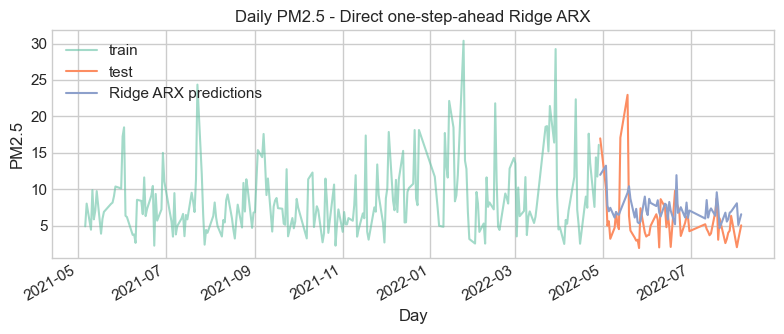

In [74]:
# Plot the full training history for context, then overlay the test values and forecasts.
ridge_arx_plot_train_target = train_df.set_index('date')['dublin_daily_avg_pm25']

fig, ax = plt.subplots(figsize=(8, 3.5))
ridge_arx_plot_train_target.plot(ax=ax, label='train', alpha=0.6)
ridge_arx_results['y_true'].plot(ax=ax, label='test')
ridge_arx_results['y_hat_ridge_arx'].plot(ax=ax, label='Ridge ARX predictions')
ax.set_title('Daily PM2.5 - Direct one-step-ahead Ridge ARX')
ax.legend()
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()


In [75]:
# Recover the fitted coefficients after preprocessing so the model remains interpretable even after scaling and weekday encoding.
# Sorting by absolute size makes it easier to see which fitted signals are strongest.
ridge_arx_feature_names = [
    feature.replace('scale_numeric__', '').replace('encode_day__', '')
    for feature in ridge_arx_model.named_steps['preprocessor'].get_feature_names_out()
]

ridge_arx_coefficients = (
    pd.DataFrame({
        'feature': ridge_arx_feature_names,
        'coefficient': ridge_arx_model.named_steps['ridge'].coef_,
    })
    .assign(abs_coefficient=lambda x: x['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
    .drop(columns='abs_coefficient')
    .reset_index(drop=True)
)

display(ridge_arx_coefficients)


,feature,coefficient
0,lag_1,1.344726
1,sun_lag_1,1.062871
2,day_of_week_1,0.878287
3,g_rad_lag_1,-0.716304
4,mintp_lag_1,-0.516422
5,day_of_week_2,-0.501336
6,day_of_week_4,0.403575
7,wdsp_lag_1,-0.331423
8,hg_lag_1,-0.243617
9,day_of_week_3,-0.214012


#### Verdict
- The direct one-step-ahead Ridge ARX model improves on the `y_hat_t = y_(t-1)` baseline, lowering RMSE from `3.868` to `3.722`.
- That improvement is modest relative to the added model complexity, which suggests that most predictive power still comes from short-run PM2.5 persistence.
- Weather and traffic appear to add some incremental signal, but not enough to materially change forecast accuracy in this dataset.
- We therefore retain Ridge ARX as a reasonable full model, but do not prioritise heavy further tuning at this stage.


### Random Forest
A random forest model was chosen as it works well on small datasets such as ours and does not require extensive tuning.

 Train: 2021-05-11 00:00:00 --- 2022-04-28 00:00:00 n=225
 Test:  2022-04-29 00:00:00 --- 2022-08-03 00:00:00 n=57
Best params: {'n_estimators': 300, 'max_depth': 3, 'min_samples_leaf': 1} | CV RMSE: 5.0726
Test RMSE: 4.583
Test MAE:  3.610
Test MAPE: 89.35%
               y_true      y_hat
2022-04-29  10.190971  11.635652
2022-05-03   4.984631  12.425648
2022-05-04   5.605879   7.420762
2022-05-05   3.196438   7.615490
2022-05-06   4.700539   7.476332
2022-05-09   6.852294   7.540690
2022-05-10   5.132344   7.123095
2022-05-11   4.519912   7.488922
2022-05-12  17.076690   7.492046
2022-05-13  22.958774   7.901382


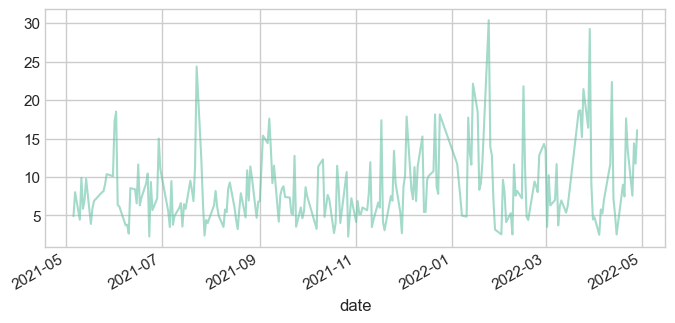

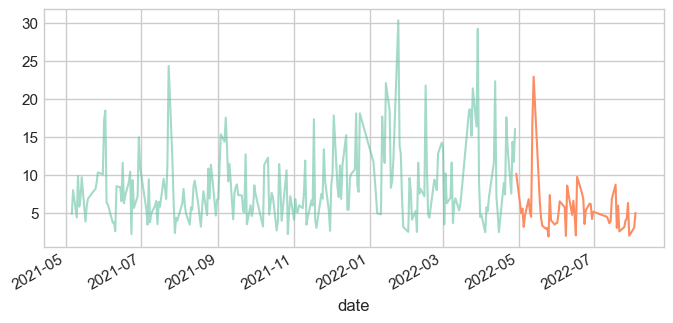

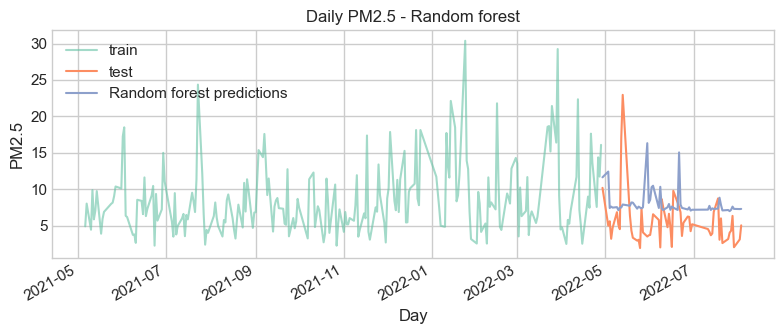

In [183]:
# Same data prep as for ridge arx without factoring the day of the week variable
rf_df = shared_model_df.copy()

rf_lagged_exog_source_cols = [
    'maxtp', 'mintp', 'wdsp', 'hg', 'sun', 'g_rad', 'evap',
    'dublin_daily_mean_site_traffic',
]

for col in rf_lagged_exog_source_cols:
    rf_df[f'{col}_lag_1'] = rf_df[col].shift(1)

rf_numeric_feature_cols = [
    'lag_1', 'lag_2', 'lag_3',
] + [f'{col}_lag_1' for col in rf_lagged_exog_source_cols]

rf_calendar_feature_cols = ['day_of_week']
rf_target_col = 'target'
rf_all_feature_cols = rf_calendar_feature_cols + rf_numeric_feature_cols

rf_df['target'] = rf_df['dublin_daily_avg_pm25'].shift(-1)

rf_df = rf_df[
    ['date'] + rf_calendar_feature_cols + rf_numeric_feature_cols + ['target']
].dropna().reset_index(drop=True)

rf_train = rf_df[rf_df['date'] <= train_df['date'].max()].copy().dropna().reset_index(drop=True)
rf_test  = rf_df[rf_df['date'] >= test_df['date'].min()].copy().dropna().reset_index(drop=True)

print(f" Train: {rf_train['date'].min()} --- {rf_train['date'].max()} n={len(rf_train)}")
print(f" Test:  {rf_test['date'].min()} --- {rf_test['date'].max()} n={len(rf_test)}")

X_train = rf_train[rf_all_feature_cols].values
y_train = rf_train[rf_target_col].values
X_test  = rf_test[rf_all_feature_cols].values
y_test  = rf_test[rf_target_col].values

# random forest does not require scaling but to maintain consistency, I tuned the n_estimators and max_depth
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [3, 5, 10, None],
    'min_samples_leaf': [1, 2, 5],
}

best_params, best_rmse = None, np.inf

for n_est in param_grid['n_estimators']:
    for max_d in param_grid['max_depth']:
        for min_leaf in param_grid['min_samples_leaf']:
            fold_rmses = []
            for tr_idx, val_idx in tscv.split(X_train):
                X_tr, X_val = X_train[tr_idx], X_train[val_idx]
                y_tr, y_val = y_train[tr_idx], y_train[val_idx]

                rf = RandomForestRegressor(
                    n_estimators=n_est,
                    max_depth=max_d,
                    min_samples_leaf=min_leaf,
                    random_state=42
                )
                rf.fit(X_tr, y_tr)
                preds = rf.predict(X_val)
                fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))

            mean_rmse = np.mean(fold_rmses)
            if mean_rmse < best_rmse:
                best_rmse = mean_rmse
                best_params = {'n_estimators': n_est, 'max_depth': max_d, 'min_samples_leaf': min_leaf}

print(f"Best params: {best_params} | CV RMSE: {best_rmse:.4f}")

# Final model
final_rf = RandomForestRegressor(**best_params, random_state=42)
final_rf.fit(X_train, y_train)
y_pred = final_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE:  {mae:.3f}")
print(f"Test MAPE: {mape:.2f}%")

rf_forecast_results = pd.DataFrame({
    'y_true': y_test,
    'y_hat':  y_pred,
}, index=rf_test['date'].values)

print(rf_forecast_results.head(10))

# Plot the full training history for context, then overlay the test values and forecasts.
rf_plot_train_target = train_df.set_index('date')['dublin_daily_avg_pm25']

fig, ax = plt.subplots(figsize=(8, 3.5))
rf_plot_train_target.plot(ax=ax, label='train', alpha=0.6)
rf_forecast_results['y_true'].plot(ax=ax, label='test')
rf_forecast_results['y_hat'].plot(ax=ax, label='Random forest predictions')
ax.set_title('Daily PM2.5 - Random forest')
ax.legend()
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

The results were ultimately much poorer than the baseline and significantly worse than the Ridge Arx method, with an RMSE of 4.583. Though this model is not computationally expensive, its ease does not make up for its poor predictive power. It may be beneficial to further tweak hyperparameters or decrease the number of features.

## 10. Inter-model evaluation